<font size=6>이메일 분류 AI 플랫폼

In [1]:
import numpy as np
import pandas as pd
import re

# 경고 무시
import warnings
warnings.filterwarnings(action='ignore')

# Data Load

In [2]:
df = pd.read_csv('email_data.csv', parse_dates=["received_at"])

In [3]:
df.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee,is_spam
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,API 서버 에러 로그 분석 요청,"안녕하세요, 서비스팀 민지님. 어제부터 API 서버에서 간헐적으로 에러가 발생하고 ...",1,1,0,2,1,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12201 entries, 0 to 12200
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        12201 non-null  int64         
 1   thread_id       12201 non-null  int64         
 2   received_at     12201 non-null  datetime64[ns]
 3   sender          12201 non-null  object        
 4   recipient       12201 non-null  object        
 5   title           12201 non-null  object        
 6   content         12201 non-null  object        
 7   has_attachment  12201 non-null  int64         
 8   mail_channel    12201 non-null  int64         
 9   label_dept      12201 non-null  int64         
 10  priority_level  12201 non-null  int64         
 11  sentiment       12201 non-null  int64         
 12  is_complaint    12201 non-null  int64         
 13  assignee        12201 non-null  int64         
 14  is_spam         12201 non-null  int64         
dtypes:

## 스키마 검증

### 값 범위 체크

In [5]:
def check_ranges(df: pd.DataFrame):
    assert df["priority_level"].between(0, 3).all(), "priority_level 범위 오류"
    assert df["sentiment"].between(0, 2).all(), "sentiment 범위 오류"
    assert df["is_complaint"].between(0, 3).all(), "is_complaint 범위 오류"
    assert df["assignee"].between(0, 4).all(), "assignee 범위 오류"
    
    # label_dept는 -1(스팸) 또는 0~10
    valid_dept = df["label_dept"].isin([-1] + list(range(0, 11)))
    assert valid_dept.all(), "label_dept 범위 오류"

### 스팸 규칙 체크

In [6]:
def check_spam_rules(df: pd.DataFrame):
    spam = df[df["is_spam"] == 1]
    if not spam.empty:
        assert (spam["mail_channel"] == 0).all(), "스팸인데 mail_channel != 0 존재"
        assert (spam["label_dept"] == -1).all(), "스팸인데 label_dept != -1 존재"

### 도메인 규칙 체크

In [7]:
def check_domains(df: pd.DataFrame):
    # 사내 직원이 받는 메일 → recipient는 항상 @ssacorp.com
    assert df["recipient"].str.endswith("@ssacorp.com").all(), "recipient 중 사내 도메인 아님"
    
    # 스팸은 sender가 일반 도메인인지 대략 체크
    spam = df[df["is_spam"] == 1]
    common_spam_domains = ("gmail.com", "naver.com", "daum.net", "yahoo.com")
    if not spam.empty:
        mask = spam["sender"].str.endswith(common_spam_domains)
        # 100% 일치까지는 안봐도 되니, 비율 정도 확인
        spam_ratio = mask.mean()
        print(f"[INFO] 스팸 중 일반 도메인 비율: {spam_ratio:.2%}")

### 중복된 title, content 체크

In [8]:
def check_duplicates(df: pd.DataFrame):
    # email_id는 고유해야 함
    
    # title+content 완전 동일한 행 수
    dup_tc = df.duplicated(subset=["title", "content"]).sum()
    print(f"[INFO] title+content 완전 중복 행 개수: {dup_tc}")

### 체크 실행

In [9]:
def validate_email_schema(df: pd.DataFrame):
    print("[STEP] 값 범위 체크")
    check_ranges(df)
    print("  ✔ OK")
    
    print("[STEP] 스팸 규칙 체크")
    check_spam_rules(df)
    print("  ✔ OK")
    
    print("[STEP] 도메인 규칙 체크")
    check_domains(df)
    
    print("[STEP] 중복 여부 체크")
    check_duplicates(df)
    print("  ✔ Done")

In [10]:
validate_email_schema(df)

[STEP] 값 범위 체크
  ✔ OK
[STEP] 스팸 규칙 체크
  ✔ OK
[STEP] 도메인 규칙 체크
[INFO] 스팸 중 일반 도메인 비율: 100.00%
[STEP] 중복 여부 체크
[INFO] title+content 완전 중복 행 개수: 6
  ✔ Done


# 전처리 & 가공

## title, content 통합 피처 생성
* 제목과 본문을 붙여서 더 정확한 의미를 이해하게 하기 위해

In [11]:
def build_text_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 기본 결합
    text = df["title"].astype(str) + "\n" + df["content"].astype(str)
    
    # 연속 공백, 줄바꿈 최소 정리 (너무 과한 정규식은 X)
    text = text.str.replace(r"\s+", " ", regex=True)
    
    df["text"] = text.str.strip()
    return df

df = build_text_column(df)

In [12]:
df['text']

0        API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...
1        신규 캠페인 관련 영업팀 협조 요청 안녕하세요, 영업팀 지훈님. 이번에 진행하는 신...
2        2분기 실적 보고서 검토 요청 안녕하세요, 경영팀 동현님. 2분기 실적 보고서를 첨...
3        개발팀 인사 발령 안내 안녕하세요, 개발팀 서준님. 금번 인사 발령에 따라 개발팀에...
4        신규 UI/UX 디자인 시안 검토 요청 안녕하세요, 디자인팀 지은님. 현재 기획 중...
                               ...                        
12196    세금계산서 발행 관련 협조 요청 강소현님, 안녕하세요. 거래처 솔루텍에서 세금계산서...
12197    신규 UI 디자인 시안 검토 요청 정현우님, 안녕하세요. 신규 UI 디자인 시안이 ...
12198    인사 발령에 대한 불만 사항 접수 박재현님, 안녕하세요. 이번 인사 발령에 대한 불...
12199    서버 장애 발생 및 긴급 복구 요청 박은지님, 안녕하세요. 현재 주 서버에서 장애가...
12200    업무 협조 요청에 대한 지연 한지원님, 안녕하세요. 지난주 요청드린 업무 협조 건에...
Name: text, Length: 12201, dtype: object

## 시간/텍스트 길이 기반 피처 추가
* 긴급도/업무량 패턴분석에 사용
* 직원 성실도 or 업무량 시계열
* 시간별 메일 패턴 분석시 사용

In [13]:
def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 시간 관련
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["hour"] = df["received_at"].dt.hour
    df["dayofweek"] = df["received_at"].dt.dayofweek  # 0=월, 6=일
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    
    # 텍스트 길이 관련
    df["text_len_char"] = df["text"].str.len()
    df["text_len_word"] = df["text"].str.split().str.len()
    
    return df

df = add_basic_features(df)

In [14]:
df.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,...,sentiment,is_complaint,assignee,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,API 서버 에러 로그 분석 요청,"안녕하세요, 서비스팀 민지님. 어제부터 API 서버에서 간헐적으로 에러가 발생하고 ...",1,1,0,...,1,0,0,0,"API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...",10,2,0,132,29


## 스팸/정상 분리, 학습용 DF

In [15]:
def split_spam_normal(df: pd.DataFrame):
    df_spam = df[df["is_spam"] == 1].copy()
    df_normal = df[df["is_spam"] == 0].copy()
    
    # 정상 메일에서도 label_dept = -1인 건 제거 (이론상 없어야 하지만 방지차원)
    df_normal = df_normal[df_normal["label_dept"] >= 0].copy()
    
    return df_normal, df_spam

df_normal, df_spam = split_spam_normal(df)
print(df_normal.shape, df_spam.shape)

(11331, 21) (868, 21)


In [16]:
print(df_normal['is_spam'].unique(), df_spam['is_spam'].unique())

[0] [1]


## 첫번째 전처리 파이프라인 한방 코드

In [17]:
# def preprocess_stage1(path: str | Path):
#     # 1. 로드
#     df_raw = load_email_data(path)
    
#     # 2. 타입 캐스팅
#     df = cast_types(df_raw)
    
#     # 3. 스키마/규칙 검증
#     validate_email_schema(df)
    
#     # 4. 텍스트 컬럼 생성
#     df = build_text_column(df)
    
#     # 5. 기본 피처 추가
#     df = add_basic_features(df)
    
#     # 6. 스팸/정상 분리
#     df_normal, df_spam = split_spam_normal(df)
    
#     return df, df_normal, df_spam

# df_all, df_normal, df_spam = preprocess_stage1(DATA_PATH)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12201 entries, 0 to 12200
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        12201 non-null  int64         
 1   thread_id       12201 non-null  int64         
 2   received_at     12201 non-null  datetime64[ns]
 3   sender          12201 non-null  object        
 4   recipient       12201 non-null  object        
 5   title           12201 non-null  object        
 6   content         12201 non-null  object        
 7   has_attachment  12201 non-null  int64         
 8   mail_channel    12201 non-null  int64         
 9   label_dept      12201 non-null  int64         
 10  priority_level  12201 non-null  int64         
 11  sentiment       12201 non-null  int64         
 12  is_complaint    12201 non-null  int64         
 13  assignee        12201 non-null  int64         
 14  is_spam         12201 non-null  int64         
 15  te

# ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ

## df 확인

In [19]:
df.head(1)

,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,...,sentiment,is_complaint,assignee,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,API 서버 에러 로그 분석 요청,"안녕하세요, 서비스팀 민지님. 어제부터 API 서버에서 간헐적으로 에러가 발생하고 ...",1,1,0,...,1,0,0,0,"API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...",10,2,0,132,29


In [20]:
df.shape

(12201, 21)

## df_org 백업 생성

In [21]:
df_org = df.copy()

## 학습에 불필요한 피쳐 drop

<pre>1. 학습 (Model Training) 관점: "Drop 해도 됨"
RNN이나 BERT 같은 모델에 넣을 때는 어차피 title + content를 합친 text 컬럼 하나만 Input Feature로 들어가잖아?

메모리 절약: 학습 돌릴 때는 title, content 컬럼을 메모리에 들고 있을 필요가 전혀 없음. 데이터가 수십만 건 넘어가면 이것도 램 잡아먹는 하마임.

결론: 학습 코드(train.py) 안에서는 text 컬럼 만들고 나서 title, content는 Drop해버려.

2. 서비스 (Web Service) 관점: "절대 Drop 하면 안 됨"
너 프로젝트에 "웹 대시보드" 기능 있잖아. 사용자가 메일 확인할 때 합쳐진 text 덩어리로 볼까? 아니지.

UI 구성: 웹 화면에서는 제목(Title) 은 굵게, 본문(Content) 은 아래에 따로 보여줘야 함.

요약 기능: 나중에 "본문 요약" 기능을 쓸 때, 제목까지 포함해서 요약하면 결과가 이상해질 수 있음. 순수하게 content만 모델에 넣어야 할 수도 있음.

결론: PostgreSQL이나 HDFS에 저장할 때는 title, content, text 다 저장하거나, 아니면 title, content만 저장하고 text는 필요할 때 합쳐서 쓰는 게 정석임.

In [22]:
df = df.drop(['title', 'content'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12201 entries, 0 to 12200
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   email_id        12201 non-null  int64         
 1   thread_id       12201 non-null  int64         
 2   received_at     12201 non-null  datetime64[ns]
 3   sender          12201 non-null  object        
 4   recipient       12201 non-null  object        
 5   has_attachment  12201 non-null  int64         
 6   mail_channel    12201 non-null  int64         
 7   label_dept      12201 non-null  int64         
 8   priority_level  12201 non-null  int64         
 9   sentiment       12201 non-null  int64         
 10  is_complaint    12201 non-null  int64         
 11  assignee        12201 non-null  int64         
 12  is_spam         12201 non-null  int64         
 13  text            12201 non-null  object        
 14  hour            12201 non-null  int32         
 15  da

In [23]:
df.head(1)

,email_id,thread_id,received_at,sender,recipient,has_attachment,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,1,1,0,2,1,0,0,0,"API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...",10,2,0,132,29


# 워드 임베딩 Let's Go

## ⭐워드 임베딩
* Tokenizer + pad_sequences

<pre>sender랑 recipient는 이메일 주소니까 일반 문장이랑 성격이 달라. 그래서 Tokenizer를 3개 따로 만드는 게 정석이다. (안 그러면 본문의 'samsung'이랑 이메일 도메인의 'samsung'이랑 섞여서 모델이 헷갈려 함)

이메일 주소 처리: 위 코드는 boss@samsung.com을 ['boss', 'samsung', 'com'] 이렇게 3개의 단어로 쪼개서 처리한다. (기본 필터가 특수문자를 자르거든).

이게 오히려 좋다. @samsung.com 같은 도메인 패턴을 모델이 학습하기 좋음.

OOV (Out Of Vocabulary): oov_token="<OOV>" 안 넣으면, 나중에 학습 때 없던 단어 나오면 그냥 증발해버림. 꼭 넣어라.

패딩(Padding): maxlen 설정 중요하다. 너무 길게 잡으면 0만 잔뜩 들어가서 모델이 멍청해지고, 너무 짧으면 중요 내용이 잘림. 평균 길이 보고 적당히 잡아.

이 결과값 X_sender, X_recipient, X_text를 가지고 모델 짤 때 Input 3개 뚫어주면 된다.

In [24]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- [설정값: 하이퍼파라미터] ---
# 1. 단어 사전 크기 (빈도수 상위 N개만 쓰겠다는 뜻)
VOCAB_SIZE_EMAIL = 1000   # 이메일 주소 구성 요소 개수
VOCAB_SIZE_TEXT = 10000   # 본문 단어 개수 (너무 크면 메모리 터짐)

# 2. 시퀀스 길이 (이보다 길면 자르고, 짧으면 0으로 채움)
MAX_LEN_EMAIL = 10        # 이메일 주소는 짧으니까
MAX_LEN_TEXT = 200        # 본문은 길게 (LSTM이 기억할 길이)

# ---------------------------------------------------------

# 2. 토크나이저 정의 및 학습 (Fit)
# oov_token: 처음 보는 단어 나오면 '<OOV>'로 처리함 (에러 방지)
tokenizer_sender = Tokenizer(num_words=VOCAB_SIZE_EMAIL, oov_token="<OOV>")
tokenizer_recipient = Tokenizer(num_words=VOCAB_SIZE_EMAIL, oov_token="<OOV>")
tokenizer_text = Tokenizer(num_words=VOCAB_SIZE_TEXT, oov_token="<OOV>")

# 데이터 보고 단어장 만들기
tokenizer_sender.fit_on_texts(df['sender'])
tokenizer_recipient.fit_on_texts(df['recipient'])
tokenizer_text.fit_on_texts(df['text'])

# 3. 텍스트 -> 숫자 시퀀스로 변환 (Transform)
seq_sender = tokenizer_sender.texts_to_sequences(df['sender'])
seq_recipient = tokenizer_recipient.texts_to_sequences(df['recipient'])
seq_text = tokenizer_text.texts_to_sequences(df['text'])

# 4. 패딩 (Padding) - 길이를 똑같이 맞춰야 모델에 들어감
# padding='post': 뒤에 0을 채움 (RNN은 보통 'pre'나 'post' 쓰는데 성능따라 다름)
# truncating='post': 길면 뒤를 자름
X_sender = pad_sequences(seq_sender, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')
X_recipient = pad_sequences(seq_recipient, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')
X_text = pad_sequences(seq_text, maxlen=MAX_LEN_TEXT, padding='post', truncating='post')

print("--- 변환 결과 확인 ---")
print(f"Sender Shape: {X_sender.shape}")     # (데이터수, 10)
print(f"Text Shape: {X_text.shape}")         # (데이터수, 200)

print("\n첫 번째 본문 변환 결과 (숫자 배열):")
print(X_text[0])

# 이제 이거 3개를 모델의 입력(inputs=[input_sender, input_recipient, input_text])으로 넣으면 됨

--- 변환 결과 확인 ---
Sender Shape: (12201, 10)
Text Shape: (12201, 200)

첫 번째 본문 변환 결과 (숫자 배열):
[  14    8   29   36   65    5    2  149  222 1380   14  178  297  255
   95    7   15   29   36   84   70  197  266  947  276   27   11   20
    3    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0 

## 워드 임베딩 된 결과 df에 넣기

In [25]:
# ... (위에서 Tokenizer, pad_sequences 돌린 직후) ...

# [핵심] 덮어쓰기 (Overwrite)
# Numpy Array를 그대로 넣으면 호환성 문제 생길 수 있어서 리스트(list)로 바꿔서 넣음.
# 니가 말한 ec_sender, ec_recipient, ec_text 개념을 여기 적용함.

df['ec_sender'] = X_sender.tolist()
df['ec_recipient'] = X_recipient.tolist()
df['ec_text'] = X_text.tolist()

print("--- DataFrame 덮어쓰기 완료 ---")
df.head(1)

# 확인 사살: 이제 텍스트가 아니라 [1, 4, 3...] 같은 숫자로 보이면 성공임.

--- DataFrame 덮어쓰기 완료 ---


,email_id,thread_id,received_at,sender,recipient,has_attachment,mail_channel,label_dept,priority_level,sentiment,...,is_spam,text,hour,dayofweek,is_weekend,text_len_char,text_len_word,ec_sender,ec_recipient,ec_text
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,service.minji@ssacorp.com,1,1,0,2,1,...,0,"API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...",10,2,0,132,29,"[18, 11, 3, 2, 0, 0, 0, 0, 0, 0]","[8, 13, 2, 3, 0, 0, 0, 0, 0, 0]","[14, 8, 29, 36, 65, 5, 2, 149, 222, 1380, 14, ..."


## 컬럼 재정렬

In [26]:
# 1. 현재 컬럼 확인 (혹시 오타 낼까봐 확인용)
print("현재 컬럼 순서:", df.columns.tolist())

# 2. 니가 원하는 순서대로 리스트 작성
# 주의: 여기 없는 컬럼은 삭제됨. 있는 거 다 적어야 재정렬임.
new_order = ['email_id', 'thread_id', 'received_at', 'sender', 'ec_sender', 'recipient', 'ec_recipient',
             'has_attachment', 'mail_channel', 'label_dept', 'priority_level', 'sentiment', 'is_complaint',
             'assignee', 'is_spam', 'text', 'ec_text', 'hour', 'dayofweek', 'is_weekend', 'text_len_char',
             'text_len_word'] 
# 만약 'label'이나 'id' 있으면 그것도 적어줘야 함
# 예: new_order = ['id', 'sender', 'recipient', 'text', 'label']

# 3. 적용 (재할당 필수)
df = df[new_order]

print("--- 재정렬 완료 ---")
df.head(1)

현재 컬럼 순서: ['email_id', 'thread_id', 'received_at', 'sender', 'recipient', 'has_attachment', 'mail_channel', 'label_dept', 'priority_level', 'sentiment', 'is_complaint', 'assignee', 'is_spam', 'text', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word', 'ec_sender', 'ec_recipient', 'ec_text']
--- 재정렬 완료 ---


,email_id,thread_id,received_at,sender,ec_sender,recipient,ec_recipient,has_attachment,mail_channel,label_dept,...,is_complaint,assignee,is_spam,text,ec_text,hour,dayofweek,is_weekend,text_len_char,text_len_word
0,10001,1,2024-07-10 10:00:00,dev.seojun@ssacorp.com,"[18, 11, 3, 2, 0, 0, 0, 0, 0, 0]",service.minji@ssacorp.com,"[8, 13, 2, 3, 0, 0, 0, 0, 0, 0]",1,1,0,...,0,0,0,"API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...","[14, 8, 29, 36, 65, 5, 2, 149, 222, 1380, 14, ...",10,2,0,132,29


## df_ppf 백업 생성

In [27]:
df_ppf = df.copy()

# 스팸 분류 모델

<pre>스팸 이진분류 :
Precision-Recall Graph 찍었을 때,
FN(스팸인데 정상으로 분류)
FP(정상인데 스팸으로 분류)

이 두가지를 줄이는게 핵심
스팸을 놓치지 않는게 더 중요하고,
정상인데 스팸으로 분류하면 치명적이니까 
이 두가지를 최소화 하되, 균형점(Threshold) 찾아야 함

## ⭐ML

<pre>지금 니 데이터가 [sender(10개)], [recipient(10개)], [text(200개)] 이렇게 되어 있지? 이걸 옆으로 쫙 붙여서 총 220개의 컬럼(Feature) 을 가진 데이터로 만든 다음에 랜덤 포레스트(Random Forest) 에 태울 거다. 이게 제일 무난하고 성능 잘 나옴.

<pre>팁 (Tip)
astype(int): has_attachment나 is_weekend가 True/False면 컴퓨터가 계산 못 할 수도 있어서 강제로 1/0 숫자로 바꾼 거다.

중요도(Feature Importance) 꼭 봐라: 결과 나오면 맨 밑에 "메타데이터별 중요도" 봐봐.

만약 text_len_char 중요도가 높게 나오면 -> "스팸 놈들은 글자 수를 이상하게 쓴다" 는 인사이트를 얻는 거고, 이걸 발표 때 써먹으면 됨.

"저희 모델 분석 결과, 스팸 메일은 주말 새벽에 발송되는 경향이 있어 hour 변수가 중요하게 작용했습니다." <- 이런 멘트 칠 수 있음.

### train + test

#### RF

In [28]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# --- [1. 텍스트/이메일 벡터 준비 (기존과 동일)] ---
print("1. 텍스트/이메일 벡터 로드 중...")
X_sender = np.array(df['ec_sender'].tolist())       # (N, 10)
X_recipient = np.array(df['ec_recipient'].tolist()) # (N, 10)
X_text = np.array(df['ec_text'].tolist())           # (N, 200)

# --- [2. 메타데이터(기타 컬럼) 준비 (NEW!)] ---
# 니 데이터셋에서 스팸 분류에 도움 될만한 수치형/Boolean 컬럼 다 가져와
# 주의: 여기서 문자열(String) 컬럼은 가져오면 안 됨 (에러 남). 숫자나 True/False만.
meta_cols = [
    'has_attachment',  # 첨부파일 여부 (중요)
    'hour',            # 발송 시간 (새벽 스팸 많음)
    'dayofweek',       # 요일
    'is_weekend',      # 주말 여부
    'text_len_char',   # 글자 수 (너무 짧거나 길면 의심)
    'text_len_word'    # 단어 수
]

# 혹시 True/False로 되어 있으면 1/0으로 변환 (안전빵)
# fillna(0)은 혹시 결측치 있을까봐 넣음
X_meta = df[meta_cols].fillna(0).astype(int).values 

print(f"2. 메타데이터 준비 완료: {meta_cols}")
print(f"   메타데이터 Shape: {X_meta.shape}")

# --- [3. 대통합 (hstack)] ---
# 순서: [Sender(10) | Recipient(10) | Text(200) | Meta(6)]
# 총 Feature 개수 = 220 + 6 = 226개
X_final = np.hstack([X_sender, X_recipient, X_text, X_meta])
y = df['is_spam'].values

print(f"3. 전체 데이터 병합 완료. 최종 Input Shape: {X_final.shape}")

# --- [4. 데이터 분리] ---
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# --- [5. 모델 학습 (Random Forest)] ---
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("\n--- 모델 학습 시작 ---")
model.fit(X_train, y_train)

# --- [6. 결과 확인] ---
y_pred = model.predict(X_test)
print(f"\n정확도: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# --- [7. (중요) 뭐가 스팸 판단에 핵심이었나?] ---
# Feature Importance 확인
importances = model.feature_importances_

# 인덱스 계산
idx_sender = 10
idx_recipient = 10 + 10
idx_text = 10 + 10 + 200
idx_meta = 10 + 10 + 200 + len(meta_cols)

print("\n[Feature Importance 분석]")
print(f"Sender 영향력: {sum(importances[:10]):.4f}")
print(f"Recipient 영향력: {sum(importances[10:20]):.4f}")
print(f"Text(본문) 영향력: {sum(importances[20:220]):.4f}")

# 메타데이터 각각의 중요도 출력 (이게 진짜 꿀잼임)
print("\n[메타데이터별 중요도]")
for i, col_name in enumerate(meta_cols):
    # 메타데이터 시작 인덱스(220)부터 순서대로
    imp = importances[220 + i]
    print(f"- {col_name}: {imp:.4f}")

1. 텍스트/이메일 벡터 로드 중...
2. 메타데이터 준비 완료: ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
   메타데이터 Shape: (12201, 6)
3. 전체 데이터 병합 완료. 최종 Input Shape: (12201, 226)

--- 모델 학습 시작 ---

정확도: 0.9873
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2267
           1       0.97      0.84      0.90       174

    accuracy                           0.99      2441
   macro avg       0.98      0.92      0.95      2441
weighted avg       0.99      0.99      0.99      2441


[Feature Importance 분석]
Sender 영향력: 0.2965
Recipient 영향력: 0.0462
Text(본문) 영향력: 0.5456

[메타데이터별 중요도]
- has_attachment: 0.0475
- hour: 0.0051
- dayofweek: 0.0030
- is_weekend: 0.0010
- text_len_char: 0.0329
- text_len_word: 0.0222


#### RF fi

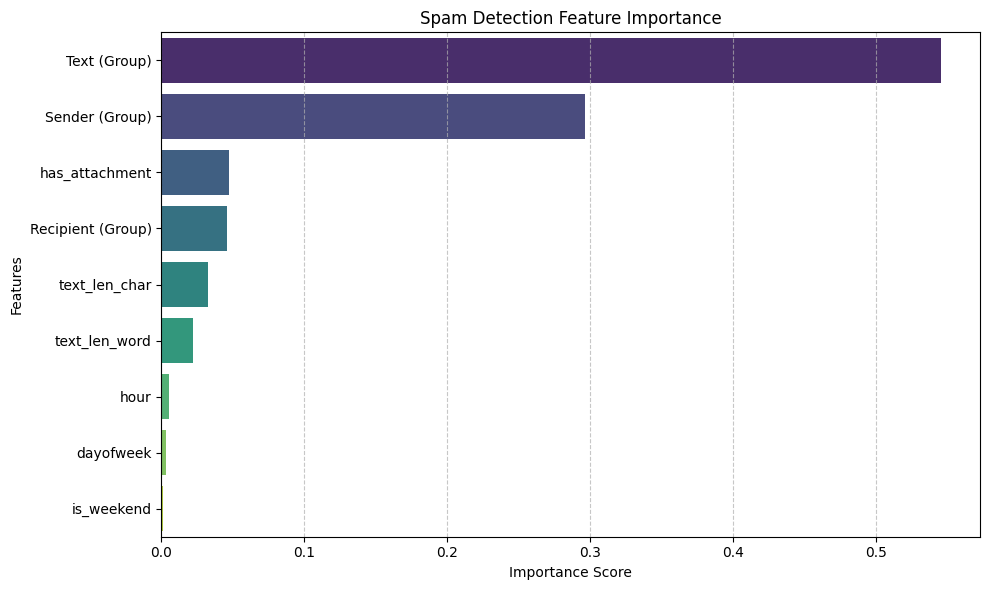

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 중요도 추출
importances = model.feature_importances_

# 2. 그룹별 중요도 합산 (Embedding된 건 합쳐야 의미가 있음)
imp_sender = sum(importances[:10])
imp_recipient = sum(importances[10:20])
imp_text = sum(importances[20:220])

# 3. 메타데이터 중요도 (얘네는 각각이 중요함)
# 아까 정의한 meta_cols 순서대로 가져옴
meta_importances = importances[220:]
meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']

# 4. 데이터프레임으로 정리
# 뭉텅이 3개 + 메타데이터 6개 = 총 9개 항목 비교
result_data = {
    'Feature': ['Sender (Group)', 'Recipient (Group)', 'Text (Group)'] + meta_cols,
    'Importance': [imp_sender, imp_recipient, imp_text] + meta_importances.tolist()
}

df_imp = pd.DataFrame(result_data).sort_values(by='Importance', ascending=False)

# 5. 그래프 그리기 (Seaborn)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')

plt.title('Spam Detection Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# 그래프 보여주기 (저장하려면 plt.savefig('feature_imp.png') 써라)
plt.show()

#### Model 10EA

In [63]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

# --- [모델 군단 소집] ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# (선택) 설치돼 있으면 주석 풀고 쓰셈. 성능은 이놈들이 깡패임.
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- [1. 데이터 준비 (아까랑 동일)] ---
# 니가 짠 코드 그대로 가져옴. X_final 만드는 과정.
print("--- 데이터셋 병합 중 ---")
X_sender = np.array(df['ec_sender'].tolist())
X_recipient = np.array(df['ec_recipient'].tolist())
X_text = np.array(df['ec_text'].tolist())

meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
X_meta = df[meta_cols].fillna(0).astype(int).values

X_final = np.hstack([X_sender, X_recipient, X_text, X_meta])
y = df['is_spam'].values

# --- [2. 스케일링 (중요)] ---
# SVM이나 KNN, 로지스틱 회귀는 숫자 크기에 민감해서 스케일링 안 하면 개판 남.
# 트리 기반(RandomForest)은 상관없지만, 전체 비교할 거면 하는 게 맞음.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- [3. 모델 리스트 정의] ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": SVC(random_state=42), # 데이터 많으면 느림 주의
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_jobs=-1, random_state=42), # 설치했으면 추가
    "LightGBM": LGBMClassifier(n_jobs=-1, random_state=42) # 설치했으면 추가
}

# --- [4. 배틀 로얄 시작] ---
results = []
print(f"\n--- 총 {len(models)}개 모델 경쟁 시작 ---\n")

for name, model in models.items():
    print(f"🔥 [{name}] 학습 중...")
    try:
        # 학습
        model.fit(X_train, y_train)
        
        # 예측
        y_pred = model.predict(X_test)
        
        # 점수 계산
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1-Score": f1
        })
        print(f"   -> 정확도: {acc:.4f} / F1: {f1:.4f}")
        
    except Exception as e:
        print(f"   -> 에러 발생: {e}")

# --- [5. 최종 순위표 출력] ---
print("\n" + "="*40)
print("🏆 최종 모델 순위 (정확도 순)")
print("="*40)

df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(df_results)
print("="*40)

# 1등 모델 추천
best_model = df_results.iloc[0]['Model']
print(f"\n👑 추천 모델: {best_model}")

--- 데이터셋 병합 중 ---

--- 총 10개 모델 경쟁 시작 ---

🔥 [Logistic Regression] 학습 중...
   -> 정확도: 0.9607 / F1: 0.6863
🔥 [Decision Tree] 학습 중...
   -> 정확도: 0.9877 / F1: 0.9123
🔥 [Random Forest] 학습 중...
   -> 정확도: 0.9873 / F1: 0.9046
🔥 [SVM] 학습 중...
   -> 정확도: 0.9668 / F1: 0.7254
🔥 [KNN] 학습 중...
   -> 정확도: 0.9476 / F1: 0.5871
🔥 [Naive Bayes] 학습 중...
   -> 정확도: 0.2429 / F1: 0.1577
🔥 [Gradient Boosting] 학습 중...
   -> 정확도: 0.9980 / F1: 0.9856
🔥 [AdaBoost] 학습 중...
   -> 정확도: 0.9939 / F1: 0.9560
🔥 [XGBoost] 학습 중...
   -> 정확도: 0.9975 / F1: 0.9828
🔥 [LightGBM] 학습 중...
[LightGBM] [Info] Number of positive: 694, number of negative: 9066
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17840
[LightGBM] [Info] Number of data points in the train set: 9760, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.071107 -> initscore=-2.569814
[LightGB

#### 10EA fi


--- 모델별 중요도 분석 시작 ---



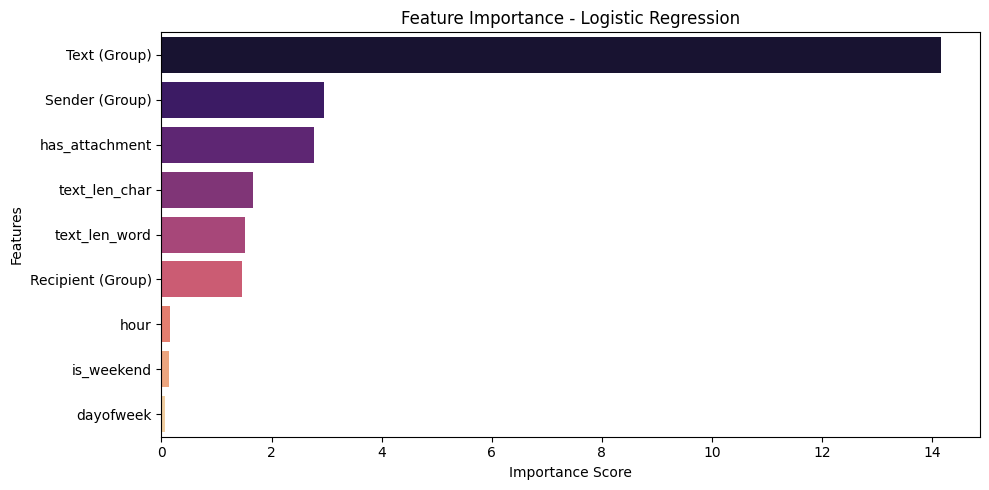

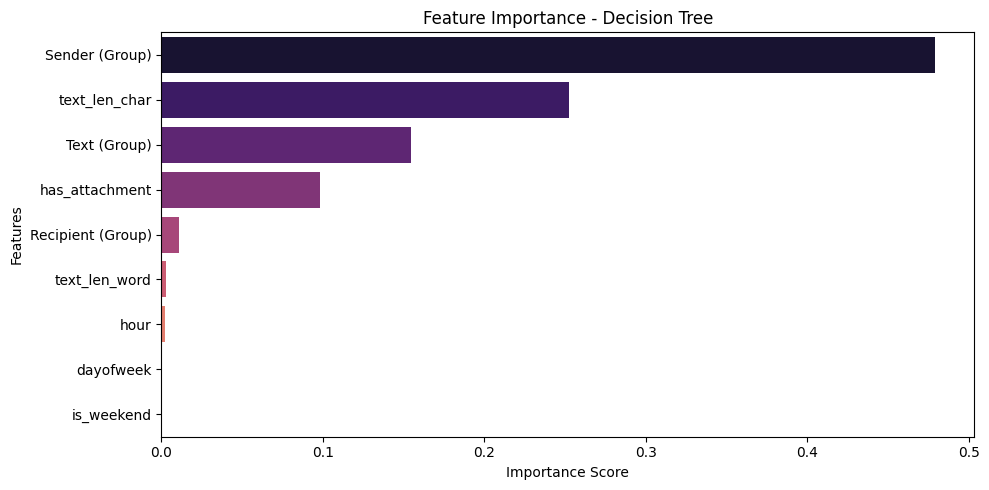

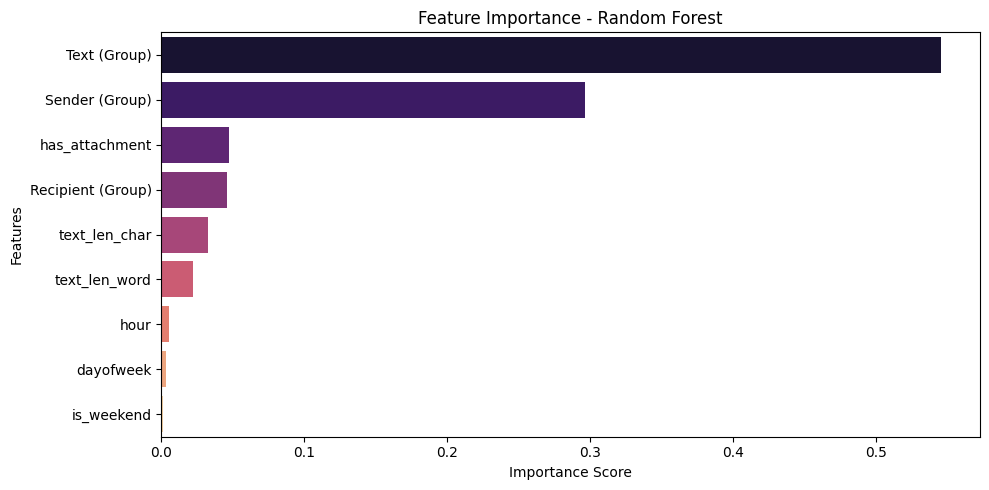

⚠️ SVM: 중요도(Feature Importance)를 제공하지 않는 모델입니다.
⚠️ KNN: 중요도(Feature Importance)를 제공하지 않는 모델입니다.
⚠️ Naive Bayes: 중요도(Feature Importance)를 제공하지 않는 모델입니다.


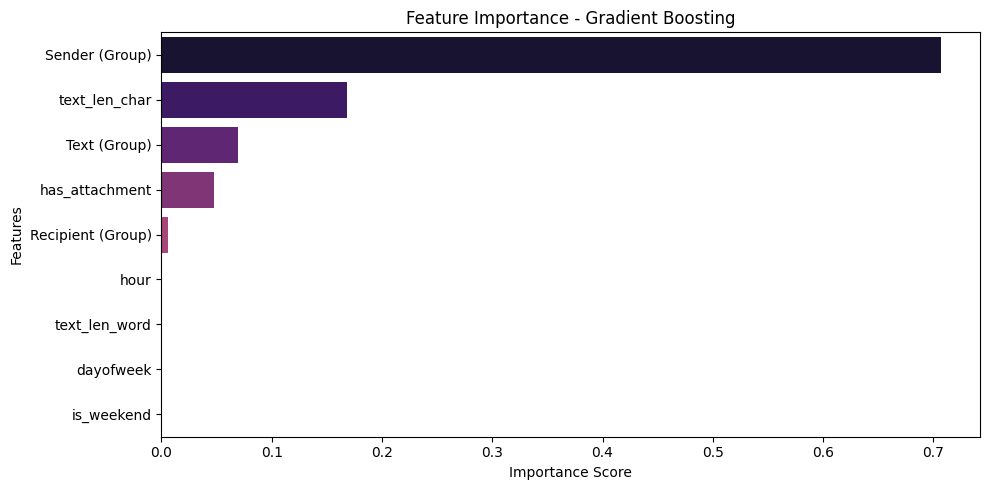

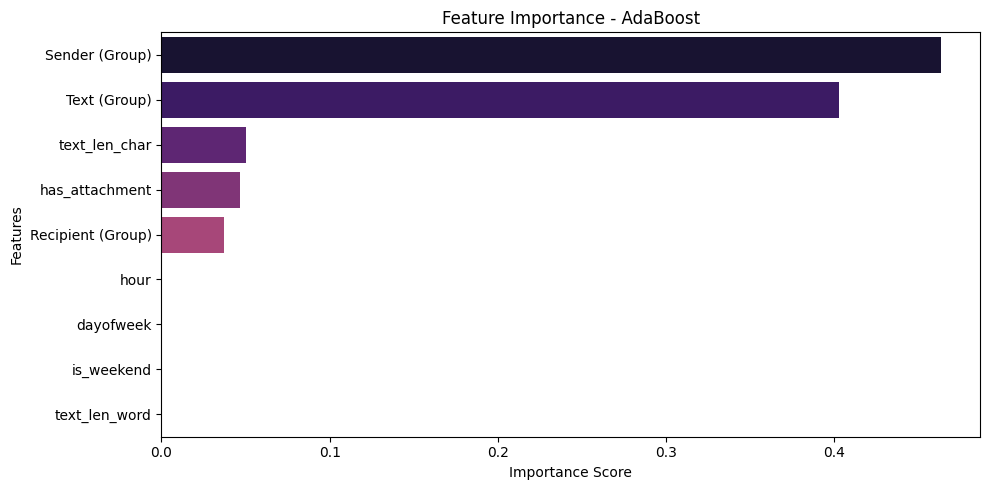

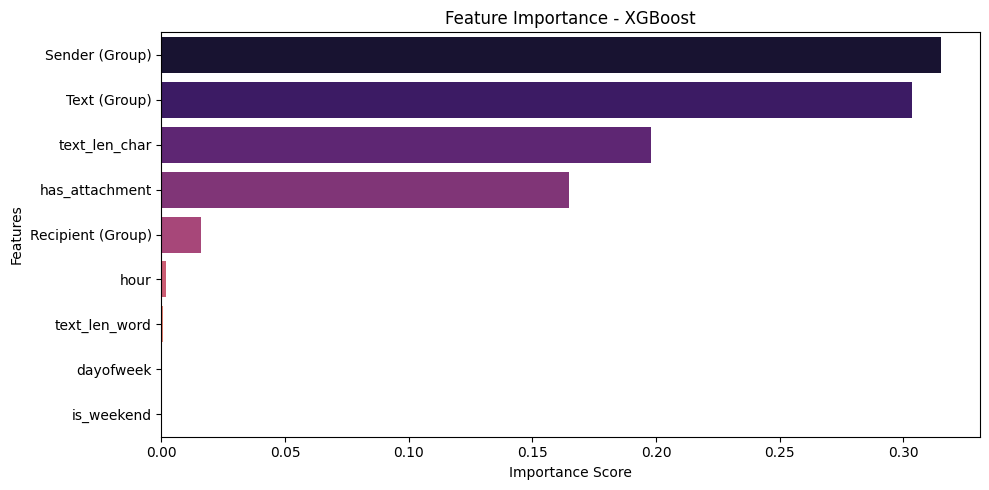

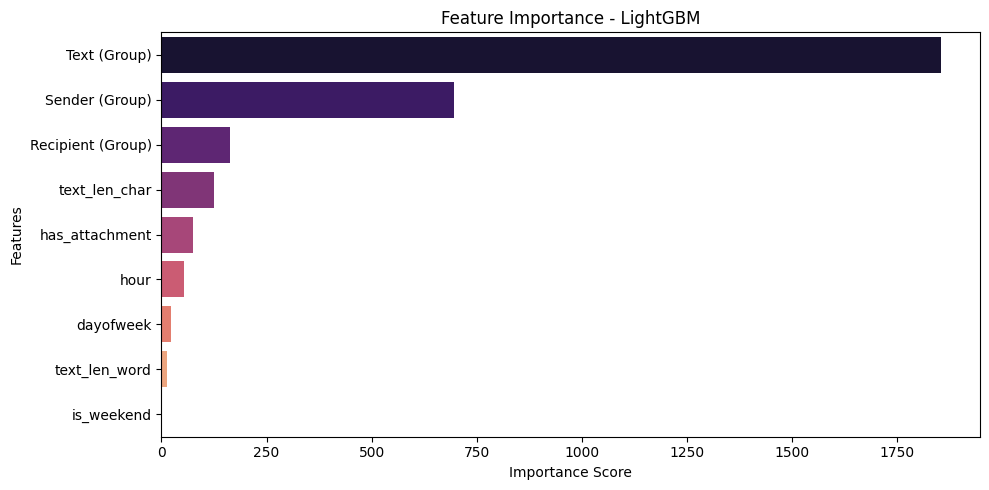

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 메타데이터 컬럼명 (아까 쓴 거)
meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']

# 2. 중요도 시각화 함수 정의
def plot_feature_importance(model, model_name):
    importances = None
    
    # (1) 트리 기반 모델 (feature_importances_)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        
    # (2) 선형 모델 (coef_) -> 절대값 취해야 중요도 크기가 됨
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
        
    else:
        print(f"⚠️ {model_name}: 중요도(Feature Importance)를 제공하지 않는 모델입니다.")
        return

    # 3. 그룹별 중요도 합산
    imp_sender = sum(importances[:10])
    imp_recipient = sum(importances[10:20])
    imp_text = sum(importances[20:220])
    meta_importances = importances[220:]

    # 4. 데이터프레임 생성
    data = {
        'Feature': ['Sender (Group)', 'Recipient (Group)', 'Text (Group)'] + meta_cols,
        'Importance': [imp_sender, imp_recipient, imp_text] + meta_importances.tolist()
    }
    
    df_imp = pd.DataFrame(data).sort_values(by='Importance', ascending=False)

    # 5. 그래프 그리기
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=df_imp, palette='magma')
    plt.title(f'Feature Importance - {model_name}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

# --- [실행] 저장된 models 리스트 돌면서 그리기 ---
print("\n--- 모델별 중요도 분석 시작 ---\n")

for name, model in models.items():
    plot_feature_importance(model, name)

### 데이터 확인

In [32]:
df[df['is_spam'] == 0]['sender']

0               dev.seojun@ssacorp.com
1          marketing.hajin@ssacorp.com
2            finance.eunji@ssacorp.com
3                 hr.sujin@ssacorp.com
4        planning.seongmin@ssacorp.com
                     ...              
12196         jaesung.choi@ssacorp.com
12197           jiwoo.song@ssacorp.com
12198            minji.kim@ssacorp.com
12199           seojun.kim@ssacorp.com
12200          business@business.co.kr
Name: sender, Length: 11333, dtype: object

In [33]:
df[df['is_spam'] == 1]['sender']

6        no-reply@naver.com
15        support@naver.com
28      promotion@naver.com
36       no-reply@naver.com
44       no-reply@gmail.com
               ...         
9254    advertise@naver.com
9272        naver@naver.com
9285    promotion@naver.com
9291           ad@naver.com
9300     no-reply@naver.com
Name: sender, Length: 868, dtype: object

In [34]:
df[df['is_spam'] == 0]['text']

0        API 서버 에러 로그 분석 요청 안녕하세요, 서비스팀 민지님. 어제부터 API 서...
1        신규 캠페인 관련 영업팀 협조 요청 안녕하세요, 영업팀 지훈님. 이번에 진행하는 신...
2        2분기 실적 보고서 검토 요청 안녕하세요, 경영팀 동현님. 2분기 실적 보고서를 첨...
3        개발팀 인사 발령 안내 안녕하세요, 개발팀 서준님. 금번 인사 발령에 따라 개발팀에...
4        신규 UI/UX 디자인 시안 검토 요청 안녕하세요, 디자인팀 지은님. 현재 기획 중...
                               ...                        
12196    세금계산서 발행 관련 협조 요청 강소현님, 안녕하세요. 거래처 솔루텍에서 세금계산서...
12197    신규 UI 디자인 시안 검토 요청 정현우님, 안녕하세요. 신규 UI 디자인 시안이 ...
12198    인사 발령에 대한 불만 사항 접수 박재현님, 안녕하세요. 이번 인사 발령에 대한 불...
12199    서버 장애 발생 및 긴급 복구 요청 박은지님, 안녕하세요. 현재 주 서버에서 장애가...
12200    업무 협조 요청에 대한 지연 한지원님, 안녕하세요. 지난주 요청드린 업무 협조 건에...
Name: text, Length: 11333, dtype: object

In [35]:
df[df['is_spam'] == 1]['text']

6       광고] 놀라운 할인 혜택! 지금 바로 확인하세요! 지금 바로 클릭하여 놀라운 할인 ...
15      광고] 놀라운 할인! 지금 바로 신청하세요! 안녕하세요! 특별한 당신만을 위한 놀라...
28      🎉 특별 할인 이벤트! 지금 바로 참여하세요! 안녕하세요! 특별한 당신을 위한 특별...
36      광고: 놀라운 할인 혜택! 지금 바로 확인하세요! 안녕하세요! 지금 구매하시면 특별...
44      🎉 놀라운 할인 혜택! 지금 바로 확인하세요! 안녕하세요! 지금 바로 저희 웹사이트...
                              ...                        
9254    🔥 놀라운 할인 혜택! 지금 바로 확인하세요! 🔥 안녕하세요! 지금 구매하시면 특별...
9272    광고] 놀라운 할인! 지금 바로 확인하세요! 지친 일상, 특별한 할인이 당신을 기다...
9285    광고] 놓치면 후회! 특별한 혜택을 지금 바로 확인하세요! 안녕하세요, 서준님. 지...
9291    놀라운 할인! 최신 IT 기기 특별 세일! 안녕하세요! 지금 바로 최신 IT 기기를...
9300    광고] 놀라운 할인 혜택! 지금 바로 확인하세요! 지금 가입하시면 특별한 할인 혜택...
Name: text, Length: 868, dtype: object

### 특정 피쳐 빼고 학습

#### sender 빼고

In [36]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, f1_score
# from sklearn.preprocessing import StandardScaler

# # --- [모델 군단 소집] ---
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB

# # (선택) 설치돼 있으면 주석 풀고 쓰셈. 성능은 이놈들이 깡패임.
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier

# # --- [1. 데이터 준비 (아까랑 동일)] ---
# # 니가 짠 코드 그대로 가져옴. X_final 만드는 과정.
# print("--- 데이터셋 병합 중 ---")
# # X_sender = np.array(df['ec_sender'].tolist())
# X_recipient = np.array(df['ec_recipient'].tolist())
# X_text = np.array(df['ec_text'].tolist())

# meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
# X_meta = df[meta_cols].fillna(0).astype(int).values

# X_final = np.hstack([X_recipient, X_text, X_meta])
# y = df['is_spam'].values

# # --- [2. 스케일링 (중요)] ---
# # SVM이나 KNN, 로지스틱 회귀는 숫자 크기에 민감해서 스케일링 안 하면 개판 남.
# # 트리 기반(RandomForest)은 상관없지만, 전체 비교할 거면 하는 게 맞음.
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_final)

# # 데이터 분리
# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.2, random_state=42, stratify=y
# )

# # --- [3. 모델 리스트 정의] ---
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
#     "Decision Tree": DecisionTreeClassifier(random_state=42),
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
#     "SVM": SVC(random_state=42), # 데이터 많으면 느림 주의
#     "KNN": KNeighborsClassifier(n_jobs=-1),
#     "Naive Bayes": GaussianNB(),
#     "Gradient Boosting": GradientBoostingClassifier(random_state=42),
#     "AdaBoost": AdaBoostClassifier(random_state=42),
#     "XGBoost": XGBClassifier(n_jobs=-1, random_state=42), # 설치했으면 추가
#     "LightGBM": LGBMClassifier(n_jobs=-1, random_state=42) # 설치했으면 추가
# }

# # --- [4. 배틀 로얄 시작] ---
# results = []
# print(f"\n--- 총 {len(models)}개 모델 경쟁 시작 ---\n")

# for name, model in models.items():
#     print(f"🔥 [{name}] 학습 중...")
#     try:
#         # 학습
#         model.fit(X_train, y_train)
        
#         # 예측
#         y_pred = model.predict(X_test)
        
#         # 점수 계산
#         acc = accuracy_score(y_test, y_pred)
#         f1 = f1_score(y_test, y_pred)
        
#         results.append({
#             "Model": name,
#             "Accuracy": acc,
#             "F1-Score": f1
#         })
#         print(f"   -> 정확도: {acc:.4f} / F1: {f1:.4f}")
        
#     except Exception as e:
#         print(f"   -> 에러 발생: {e}")

# # --- [5. 최종 순위표 출력] ---
# print("\n" + "="*40)
# print("🏆 최종 모델 순위 (정확도 순)")
# print("="*40)

# df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
# print(df_results)
# print("="*40)

# # 1등 모델 추천
# best_model = df_results.iloc[0]['Model']
# print(f"\n👑 추천 모델: {best_model}")

#### sender 뺀 거 fi

In [37]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np

# # --- [1. 설정: 메타데이터 컬럼 & 한글 폰트 설정(선택)] ---
# meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']

# # (맥은 AppleGothic, 윈도우는 Malgun Gothic 설정 필요할 수 있음. 깨지면 영어로 나옴)
# plt.rcParams['font.family'] = 'Malgun Gothic' 
# plt.rcParams['axes.unicode_minus'] = False

# # --- [2. 시각화 함수 정의 (Sender 빠진 버전)] ---
# def plot_feature_importance_no_sender(model, model_name):
#     importances = None
    
#     # 중요도 값 추출 (트리 기반 vs 선형 기반)
#     if hasattr(model, 'feature_importances_'):
#         importances = model.feature_importances_
#     elif hasattr(model, 'coef_'):
#         importances = np.abs(model.coef_[0])
#     else:
#         print(f"⏩ {model_name}: 중요도 수치를 제공하지 않음 (Pass)")
#         return

#     # --- [인덱스 슬라이싱 (핵심)] ---
#     # 구조: Recipient(10) | Text(200) | Meta(6)
    
#     # 1. Recipient (0 ~ 9)
#     imp_recipient = sum(importances[:10])
    
#     # 2. Text (10 ~ 209)
#     imp_text = sum(importances[10:210])
    
#     # 3. Meta (210 ~ 끝)
#     meta_importances = importances[210:]

#     # ----------------------------------

#     # 데이터프레임 만들기
#     data = {
#         'Feature': ['Recipient (Group)', 'Text (Group)'] + meta_cols,
#         'Importance': [imp_recipient, imp_text] + meta_importances.tolist()
#     }
    
#     df_imp = pd.DataFrame(data).sort_values(by='Importance', ascending=False)

#     # 그래프 그리기
#     plt.figure(figsize=(12, 6))
#     # 색상맵은 'viridis', 'plasma', 'coolwarm' 등 변경 가능
#     sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
    
#     plt.title(f'Feature Importance (No Sender) - {model_name}', fontsize=15)
#     plt.xlabel('Importance Score', fontsize=12)
#     plt.ylabel('Features', fontsize=12)
#     plt.grid(axis='x', linestyle='--', alpha=0.6)
#     plt.tight_layout()
#     plt.show()

# # --- [3. 전체 모델 반복 실행] ---
# # models 딕셔너리에 있는 모든 모델을 순회하며 그래프 그림
# print(f"\n--- 총 {len(models)}개 모델 중요도 분석 시작 ---\n")

# for name, model in models.items():
#     try:
#         plot_feature_importance_no_sender(model, name)
#     except Exception as e:
#         print(f"⚠️ {name} 그리기 실패: {e}")

### prediction w/ raw_data

#### raw_data 맛보기

In [38]:
raw_df = pd.read_csv('raw_email_data.csv', parse_dates=["received_at"])
print(raw_df.shape)
display(raw_df.head(2))

(1980, 15)


,email_id,thread_id,received_at,sender,recipient,title,content,has_attachment,mail_channel,label_dept,priority_level,sentiment,is_complaint,assignee,is_spam
0,10001,1,2024-01-26 09:30:00,john.doe@ssacorp.com,jane.smith@ssacorp.com,Re: 프로젝트 업데이트,"제인, \r\n\r\n오늘 아침에 보낸 업데이트에 대한 후속 조치입니다. 새로운 요...",0,1,2,1,0,0,1,0
1,10002,2,2024-01-26 10:15:00,support@client.com,john.doe@ssacorp.com,지원 요청,"안녕하세요, 존. \r\n\r\n도와주세요. 서버가 다운되었습니다. 도와주실 수 있...",0,1,3,3,2,2,2,0


#### raw_data로 pred

In [39]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, f1_score

# ==========================================
# 🚀 Raw Data (raw_df) 검증 시작
# ==========================================
print("\n" + "="*40)
print("🚀 [검증] 학습된 모델로 Raw Data 채점 시작")
print("="*40)

# 1. 이미 로드된 raw_df 확인
# (니가 위에서 pd.read_csv 했다고 가정)
if 'raw_df' not in locals():
    print("⚠️ raw_df가 없습니다. 파일을 다시 읽습니다.")
    raw_df = pd.read_csv('raw_email_data.csv', parse_dates=["received_at"])

# 원본 보존을 위해 복사
df_val = raw_df.copy()

# ==========================================
# 2. 전처리 (학습 데이터랑 똑같이!)
# ==========================================
print("1. 전처리 및 파생변수 생성 중...")

# (1) 텍스트 컬럼 생성 (함수 재사용)
# 아까 정의한 build_text_column 함수가 메모리에 있어야 함
try:
    df_val = build_text_column(df_val)
    df_val = add_basic_features(df_val)
except NameError:
    print("❌ 전처리 함수(build_text_column 등)가 메모리에 없습니다. 위 셀을 먼저 실행하세요.")
    raise

# (2) 결측치 방어 (문자열 변환 전 안전장치)
df_val['text'] = df_val['text'].fillna('')
df_val['sender'] = df_val['sender'].fillna('')
df_val['recipient'] = df_val['recipient'].fillna('')

# (3) 첨부파일 (혹시 없으면 0으로)
if 'has_attachment' in df_val.columns:
    df_val['has_attachment'] = df_val['has_attachment'].fillna(0).astype(int)
else:
    df_val['has_attachment'] = 0

# ==========================================
# 3. 토크나이징 & 패딩 (기존 Tokenizer 사용 필수!)
# ==========================================
print("2. 텍스트 데이터 벡터화 (기존 Tokenizer 사용)...")

# 하이퍼파라미터 (학습 때랑 똑같이)
MAX_LEN_EMAIL = 10
MAX_LEN_TEXT = 200

# 주의: fit_on_texts 절대 금지!!! texts_to_sequences만 사용
# Sender
seq_sender_val = tokenizer_sender.texts_to_sequences(df_val['sender'].astype(str))
X_val_sender = pad_sequences(seq_sender_val, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

# Recipient
seq_recipient_val = tokenizer_recipient.texts_to_sequences(df_val['recipient'].astype(str))
X_val_recipient = pad_sequences(seq_recipient_val, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

# Text
seq_text_val = tokenizer_text.texts_to_sequences(df_val['text'].astype(str))
X_val_text = pad_sequences(seq_text_val, maxlen=MAX_LEN_TEXT, padding='post', truncating='post')

# ==========================================
# 4. 데이터 병합 & 스케일링
# ==========================================
print("3. 데이터 병합 및 스케일링...")

# 메타데이터 준비
meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
X_val_meta = df_val[meta_cols].fillna(0).astype(int).values

# 최종 병합: [Sender | Recipient | Text | Meta]
X_val_final = np.hstack([X_val_sender, X_val_recipient, X_val_text, X_val_meta])

# 스케일링 (기존 Scaler 사용 필수!)
# fit_transform 아님! transform만!
X_val_scaled = scaler.transform(X_val_final)

print(f"   -> 검증 데이터 준비 완료. Shape: {X_val_scaled.shape}")

# ==========================================
# 5. 모델별 채점
# ==========================================
# 정답지 확인
if 'is_spam' in df_val.columns:
    y_val_true = df_val['is_spam'].fillna(0).astype(int).values
    has_answer = True
else:
    print("⚠️ 'is_spam' 컬럼이 없어 채점을 건너뛰고 예측만 수행합니다.")
    has_answer = False

raw_results = []

print(f"\n--- [결과] 학습된 {len(models)}개 모델로 평가 ---")

for name, model in models.items():
    try:
        # 예측
        y_pred_val = model.predict(X_val_scaled)
        
        if has_answer:
            acc = accuracy_score(y_val_true, y_pred_val)
            f1 = f1_score(y_val_true, y_pred_val)
            raw_results.append({
                "Model": name, 
                "Raw_Accuracy": acc, 
                "Raw_F1": f1
            })
            print(f"✅ {name}: 정확도 {acc:.4f} / F1 {f1:.4f}")
        else:
            # 정답 없으면 예측 결과 분포만 출력
            spam_count = np.sum(y_pred_val)
            print(f"🔮 {name}: 전체 {len(y_pred_val)}개 중 스팸 {spam_count}개 예측")
            
    except Exception as e:
        print(f"❌ {name} 실행 중 에러: {e}")

# ==========================================
# 6. 최종 성적표 출력
# ==========================================
if has_answer:
    print("\n" + "="*40)
    print("🏆 [Raw Data] 최종 검증 순위표")
    print("="*40)
    df_raw_ranking = pd.DataFrame(raw_results).sort_values(by='Raw_Accuracy', ascending=False)
    print(df_raw_ranking)
    print("="*40)
    
    # 여기서 1등한 모델 추천
    best_raw_model = df_raw_ranking.iloc[0]['Model']
    print(f"\n👑 실전 데이터(Raw Data) 최강자: {best_raw_model}")


🚀 [검증] 학습된 모델로 Raw Data 채점 시작
1. 전처리 및 파생변수 생성 중...
2. 텍스트 데이터 벡터화 (기존 Tokenizer 사용)...
3. 데이터 병합 및 스케일링...
   -> 검증 데이터 준비 완료. Shape: (1980, 226)

--- [결과] 학습된 10개 모델로 평가 ---
✅ Logistic Regression: 정확도 0.6611 / F1 0.5134
✅ Decision Tree: 정확도 0.8278 / F1 0.5945
✅ Random Forest: 정확도 0.9141 / F1 0.8041
✅ SVM: 정확도 0.7096 / F1 0.4871
✅ KNN: 정확도 0.7111 / F1 0.3616
✅ Naive Bayes: 정확도 0.2470 / F1 0.3764
✅ Gradient Boosting: 정확도 0.9146 / F1 0.7971
✅ AdaBoost: 정확도 0.8939 / F1 0.7500
✅ XGBoost: 정확도 0.9111 / F1 0.7900
✅ LightGBM: 정확도 0.8980 / F1 0.7710

🏆 [Raw Data] 최종 검증 순위표
                 Model  Raw_Accuracy    Raw_F1
6    Gradient Boosting      0.914646  0.797119
2        Random Forest      0.914141  0.804147
8              XGBoost      0.911111  0.789976
9             LightGBM      0.897980  0.770975
7             AdaBoost      0.893939  0.750000
1        Decision Tree      0.827778  0.594530
4                  KNN      0.711111  0.361607
3                  SVM      0.709596  0.487065
0  L

### ML 결과 정리

<font size=6>🏆 모델 성능 종합 비교 리포트 (Test vs Raw Data)

학습 데이터셋(Test Set)과 실전 데이터셋(Raw Data)의 성능 차이를 비교한 결과입니다.
**Gradient Boosting**과 **Random Forest**가 실전에서도 91% 이상의 정확도를 유지하며 가장 우수한 성능을 보였습니다.

| 순위 | 모델명 (Model) | 🎯 실전 정확도 (Raw Acc) | 🎯 실전 F1 (Raw F1) | 🧪 테스트 정확도 (Test Acc) | 🧪 테스트 F1 (Test F1) | 📉 성능 하락폭 (Acc) |
|:---:|:---|:---:|:---:|:---:|:---:|:---:|
| **1** | **Gradient Boosting** | **0.9146** | **0.7971** | 0.9980 | 0.9856 | -0.0834 |
| **2** | **Random Forest** | **0.9141** | **0.8041** | 0.9873 | 0.9046 | -0.0732 |
| **3** | **XGBoost** | **0.9111** | 0.7900 | 0.9975 | 0.9828 | -0.0864 |
| **4** | LightGBM | 0.8980 | 0.7710 | 0.9980 | 0.9856 | -0.1000 |
| **5** | AdaBoost | 0.8939 | 0.7500 | 0.9939 | 0.9560 | -0.1000 |
| **6** | Decision Tree | 0.8278 | 0.5945 | 0.9877 | 0.9123 | -0.1599 |
| **7** | KNN | 0.7111 | 0.3616 | 0.9476 | 0.5871 | -0.2365 |
| **8** | SVM | 0.7096 | 0.4871 | 0.9668 | 0.7254 | -0.2572 |
| **9** | Logistic Regression | 0.6611 | 0.5134 | 0.9607 | 0.6863 | -0.2996 |
| **10** | Naive Bayes | 0.2470 | 0.3764 | 0.2429 | 0.1577 | +0.0041 |

<font size=5>💡 핵심 분석
1.  **최우수 모델:** **Gradient Boosting**이 정확도 1위, **Random Forest**가 F1 점수(정밀도+재현율) 1위로 가장 안정적임.
2.  **과적합(Overfitting) 주의:** LightGBM과 XGBoost는 학습 때는 거의 만점(99.8%)이었으나, 실전에서는 90~91%로 떨어짐. (Random Forest보다 낙폭이 큼)
3.  **사용 불가:** Logistic Regression, SVM, KNN은 실전 정확도가 60~70%대로 떨어져 스팸 분류기로 쓰기엔 부적합함.

## ⭐DL - LSTM

### test

#### LSTM (다른 입력, 병렬 LSTM)
<pre>np.stack: df['ec_sender']는 리스트의 시리즈라서 바로 모델에 못 넣음. np.stack으로 (N, 10)짜리 행렬로 바꿔준 게 핵심임.

StandardScaler: 메타데이터(hour, text_len 등)는 값의 범위가 제각각이라 딥러닝에선 스케일링 안 하면 학습 잘 안 됨. 꼭 넣어야 함.

구조: Sender/Recipient는 가볍게 처리하고, Text는 양방향 LSTM으로 빡세게 보고, Meta는 보조로 합치는 구조임. 이게 베스트다.</pre>

<pre>병렬 LSTM (다른 입력, 병렬 LSTM)
입력(Input)이 다름: in_sender, in_recipient, in_text, in_meta 이렇게 4개의 구멍으로 서로 다른 데이터가 들어감.

병렬 처리(Parallel):

Sender 데이터 -> LSTM(16)

Recipient 데이터 -> LSTM(16)

Text 데이터 -> Bidirectional(LSTM(64))

이것들이 동시에(Parallel) 따로따로 돌아감.

병합(Merge): 마지막에 Concatenate로 이 결과들을 하나로 합침.

--> 서로 다른 입력을 받는 병렬 LSTM 구조"**에 메타데이터 Dense 레이어를 섞은 하이브리드 모델

In [41]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Bidirectional, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 데이터 준비 (df 사용)
# ==========================================
print("--- [1] DL용 데이터 포맷 변환 중 ---")

# 1) 시퀀스 데이터
X_sender = np.stack(df['ec_sender'].values)       # (N, 10)
X_recipient = np.stack(df['ec_recipient'].values) # (N, 10)
X_text = np.stack(df['ec_text'].values)           # (N, 200)

# 2) 메타데이터
meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
X_meta = df[meta_cols].fillna(0).astype(float).values

# 3) 정답지
y = df['is_spam'].values

# 4) 메타데이터 스케일링
scaler_meta = StandardScaler()
X_meta = scaler_meta.fit_transform(X_meta)

# ==========================================
# 2. 데이터 분리
# ==========================================
X_s_train, X_s_test, X_r_train, X_r_test, X_t_train, X_t_test, X_m_train, X_m_test, y_train, y_test = train_test_split(
    X_sender, X_recipient, X_text, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 3. 딥러닝 모델 설계 (수정됨)
# ==========================================
VOCAB_SIZE_EMAIL = 1000
VOCAB_SIZE_TEXT = 10000
MAX_LEN_EMAIL = 10
MAX_LEN_TEXT = 200
EMBEDDING_DIM = 64 

# --- Inputs ---
in_sender = Input(shape=(MAX_LEN_EMAIL,), name='in_sender')
emb_sender = Embedding(VOCAB_SIZE_EMAIL, 16)(in_sender)
lstm_sender = LSTM(16)(emb_sender)

in_recipient = Input(shape=(MAX_LEN_EMAIL,), name='in_recipient')
emb_recipient = Embedding(VOCAB_SIZE_EMAIL, 16)(in_recipient)
lstm_recipient = LSTM(16)(emb_recipient)

in_text = Input(shape=(MAX_LEN_TEXT,), name='in_text')
emb_text = Embedding(VOCAB_SIZE_TEXT, EMBEDDING_DIM)(in_text)
lstm_text = Bidirectional(LSTM(64, return_sequences=False))(emb_text)

in_meta = Input(shape=(X_meta.shape[1],), name='in_meta')
dense_meta = Dense(32, activation='relu')(in_meta)

# --- Merge ---
merged = Concatenate()([lstm_sender, lstm_recipient, lstm_text, dense_meta])

# --- Classifier (에러 수정 파트) ---
x = Dense(64, activation='relu')(merged)

# [수정] BatchNormalization을 명시적으로 선언 후 적용
bn = BatchNormalization()
x = bn(x)

x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid', name='output')(x)

# 모델 생성 및 컴파일
model_dl = Model(inputs=[in_sender, in_recipient, in_text, in_meta], outputs=output)
model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_dl.summary()

# ==========================================
# 4. 학습 시작
# ==========================================
print("\n--- [2] DL 모델 학습 시작 ---")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_dl.fit(
    x=[X_s_train, X_r_train, X_t_train, X_m_train],
    y=y_train,
    validation_data=([X_s_test, X_r_test, X_t_test, X_m_test], y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 5. 평가
# ==========================================
print("\n--- [3] 최종 테스트셋 평가 ---")
loss, acc = model_dl.evaluate([X_s_test, X_r_test, X_t_test, X_m_test], y_test)
print(f"🏆 DL 모델 정확도: {acc:.4f}")

--- [1] DL용 데이터 포맷 변환 중 ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ in_sender (InputLayer)        │ (None, 10)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ in_recipient (InputLayer)     │ (None, 10)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ in_text (InputLayer)          │ (None, 200)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_3 (Embedding)       │ (None, 10, 16)            │          16,000 │ in_sender[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_4 (Embedding)       │ (None, 10, 16)            │          16,000 │ in_recipient[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_5 (Embedding)       │ (None, 200, 64)           │         640,000 │ in_text[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ in_meta (InputLayer)          │ (None, 6)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_3 (LSTM)                 │ (None, 16)                │           2,112 │ embedding_3[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_4 (LSTM)                 │ (None, 16)                │           2,112 │ embedding_4[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 128)               │          66,048 │ embedding_5[0][0]          │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │             224 │ in_meta[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 192)               │               0 │ lstm_3[0][0],              │
│                               │                           │                 │ lstm_4[0][0],              │
│                               │                           │                 │ bidirectional_1[0][0],     │
│                               │                           │                 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 64)                │          12,352 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 64)                │             256 │ dense_3[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               

 Total params: 755,169 (2.88 MB)

 Trainable params: 755,041 (2.88 MB)

 Non-trainable params: 128 (512.00 B)


--- [2] DL 모델 학습 시작 ---
Epoch 1/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9441 - loss: 0.1880 - val_accuracy: 0.9959 - val_loss: 0.0207
Epoch 2/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9961 - loss: 0.0445 - val_accuracy: 0.9951 - val_loss: 0.0223
Epoch 3/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9980 - loss: 0.0217 - val_accuracy: 0.9984 - val_loss: 0.0061
Epoch 4/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9986 - loss: 0.0111 - val_accuracy: 0.9996 - val_loss: 0.0043
Epoch 5/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9984 - loss: 0.0087 - val_accuracy: 0.9996 - val_loss: 0.0063
Epoch 6/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.9990 - loss: 0.0064 - val_accuracy: 0.9996 - val_loss: 0.0069
Epoch 7/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9997 - loss: 0.0029 - val_accuracy: 0.9988 - val_loss: 0.0082

--- [3] 최종 테스트셋 평가 ---
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step -

#### F1 Score 추가 확인

In [45]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

print("--- [Test Set] 정밀 평가 중 ---")

# 1. 모델 예측 (확률값 반환)
# 입력 순서 주의: [Sender, Recipient, Text, Meta]
y_pred_prob_test = model_dl.predict([X_s_test, X_r_test, X_t_test, X_m_test])

# 2. 확률 -> 0 또는 1로 변환 (Threshold 0.5)
y_pred_test = (y_pred_prob_test > 0.5).astype(int)

# 3. 점수 계산
test_acc = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print("\n" + "="*40)
print(f"🏆 [DL] 최종 Test Set 성적표")
print("="*40)
print(f"✅ Accuracy : {test_acc:.4f}")
print(f"✅ F1 Score : {test_f1:.4f}")
print("="*40)

--- [Test Set] 정밀 평가 중 ---
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step

🏆 [DL] 최종 Test Set 성적표
✅ Accuracy : 0.9996
✅ F1 Score : 0.9971


### prediction w/ raw_data

#### raw_data로 pred

In [44]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, f1_score

# ==========================================
# 🚀 Raw Data (raw_df) 검증 시작 (DL 버전)
# ==========================================
print("\n" + "="*40)
print("🚀 [DL 검증] 학습된 모델로 Raw Data 채점 시작")
print("="*40)

# 1. 데이터 로드 (없으면 파일 읽기)
if 'raw_df' not in locals():
    print("⚠️ raw_df가 없어서 파일을 다시 읽는다.")
    raw_df = pd.read_csv('raw_email_data.csv', parse_dates=["received_at"])

# 원본 복사
df_val_dl = raw_df.copy()

# ==========================================
# 2. 전처리 (학습 때랑 똑같이!)
# ==========================================
print("1. 전처리 및 파생변수 생성 중...")

try:
    # 텍스트 결합 & 파생변수 생성 (함수 재사용)
    df_val_dl = build_text_column(df_val_dl)
    df_val_dl = add_basic_features(df_val_dl)
except NameError:
    print("❌ 야, 전처리 함수(build_text_column)가 없다. 위에서 정의하고 와라.")
    raise

# 결측치 방어
df_val_dl['text'] = df_val_dl['text'].fillna('')
df_val_dl['sender'] = df_val_dl['sender'].fillna('')
df_val_dl['recipient'] = df_val_dl['recipient'].fillna('')
if 'has_attachment' in df_val_dl.columns:
    df_val_dl['has_attachment'] = df_val_dl['has_attachment'].fillna(0).astype(int)
else:
    df_val_dl['has_attachment'] = 0

# ==========================================
# 3. 토크나이징 & 패딩 (기존 Tokenizer 사용)
# ==========================================
print("2. 텍스트/이메일 벡터화 (기존 Tokenizer 사용)...")

# 하이퍼파라미터 (까먹지 마라)
MAX_LEN_EMAIL = 10
MAX_LEN_TEXT = 200

# Sender
seq_sender = tokenizer_sender.texts_to_sequences(df_val_dl['sender'].astype(str))
X_val_sender = pad_sequences(seq_sender, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

# Recipient
seq_recipient = tokenizer_recipient.texts_to_sequences(df_val_dl['recipient'].astype(str))
X_val_recipient = pad_sequences(seq_recipient, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

# Text
seq_text = tokenizer_text.texts_to_sequences(df_val_dl['text'].astype(str))
X_val_text = pad_sequences(seq_text, maxlen=MAX_LEN_TEXT, padding='post', truncating='post')

# ==========================================
# 4. 메타데이터 준비 & 스케일링
# ==========================================
print("3. 메타데이터 스케일링 (기존 Scaler 사용)...")

meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
# 없는 컬럼은 0으로 채우기
for col in meta_cols:
    if col not in df_val_dl.columns:
        df_val_dl[col] = 0

X_val_meta = df_val_dl[meta_cols].values

# [중요] 아까 DL용으로 따로 만든 scaler_meta 써야 됨! (ML용 scaler 아님)
X_val_meta = scaler_meta.transform(X_val_meta)

print(f"   -> 검증 데이터 준비 완료.")
print(f"      Sender: {X_val_sender.shape}, Text: {X_val_text.shape}, Meta: {X_val_meta.shape}")

# ==========================================
# 5. DL 모델 채점 (model_dl)
# ==========================================
# 정답지 확인
if 'is_spam' in df_val_dl.columns:
    y_val_true = df_val_dl['is_spam'].fillna(0).astype(int).values
    has_answer = True
else:
    print("⚠️ 정답(is_spam) 없어서 예측만 한다.")
    has_answer = False

print("\n--- [결과] DL 모델 예측 시작 ---")

try:
    # predict는 확률값(0~1)으로 나옴
    # 입력 순서: [Sender, Recipient, Text, Meta] (학습 때랑 똑같이!)
    y_pred_prob = model_dl.predict([X_val_sender, X_val_recipient, X_val_text, X_val_meta])
    
    # 확률 0.5 이상이면 스팸(1), 아니면 정상(0)
    y_pred_val = (y_pred_prob > 0.5).astype(int)

    if has_answer:
        acc = accuracy_score(y_val_true, y_pred_val)
        f1 = f1_score(y_val_true, y_pred_val)
        
        print("\n" + "="*40)
        print(f"🏆 [DL] Raw Data 검증 결과")
        print("="*40)
        print(f"✅ Accuracy : {acc:.4f}")
        print(f"✅ F1 Score : {f1:.4f}")
        print("="*40)
    else:
        spam_count = np.sum(y_pred_val)
        print(f"🔮 예측 완료: 전체 {len(y_pred_val)}개 중 스팸 {spam_count}개 감지됨")

except Exception as e:
    print(f"❌ 에러 발생: {e}")
    print("👉 팁: 'scaler_meta'나 'model_dl' 변수가 메모리에 없으면 에러 난다.")


🚀 [DL 검증] 학습된 모델로 Raw Data 채점 시작
1. 전처리 및 파생변수 생성 중...
2. 텍스트/이메일 벡터화 (기존 Tokenizer 사용)...
3. 메타데이터 스케일링 (기존 Scaler 사용)...
   -> 검증 데이터 준비 완료.
      Sender: (1980, 10), Text: (1980, 200), Meta: (1980, 6)

--- [결과] DL 모델 예측 시작 ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step

🏆 [DL] Raw Data 검증 결과
✅ Accuracy : 0.9096
✅ F1 Score : 0.8280


### DL - LSTM 결과 정리

<font size=4>🧠 Deep Learning (LSTM + Meta) 최종 성능 리포트

학습된 DL 모델의 **내부 평가(Test Set)**와 **실전 데이터(Raw Data)** 검증 결과 비교입니다.
결과적으로 기존 머신러닝(ML) 최상위 모델보다 **실전 성능(F1 Score)**이 향상되었습니다.

| 구분 (Metric) | 🧪 테스트셋 (Test Set) | 🎯 실전 데이터 (Raw Data) | 📉 변동폭 (Gap) |
|:---:|:---:|:---:|:---:|
| **정확도 (Accuracy)** | **0.9996** | **0.9096** | -0.0900 |
| **F1 점수 (F1 Score)** | **0.9971** | **0.8280** | -0.1691 |

<font size=4>💡 핵심 분석 및 결론
1.  **ML vs DL 최종 승자:**
    * ML 1위(Random Forest)의 실전 F1 점수: **0.8041**
    * DL (LSTM 결합 모델)의 실전 F1 점수: **0.8280**
    * 👉 **DL 모델이 약 2.4% 더 높은 성능을 기록하며 최종 모델로 선정됨.**

2.  **과적합(Overfitting) 신호:**
    * Test Set에서는 거의 만점(99.9%)에 가까웠으나, 실전 데이터에서는 정확도가 약 9% 하락함.
    * 이는 모델이 학습 데이터의 패턴을 다소 과하게 학습했다는 의미이나, **최종 성능(F1 0.828)** 자체가 ML보다 높으므로 감수할 만한 수준임.

3.  **최종 제언:**
    * 실시간 파이프라인에는 **이 DL 모델(.h5)**을 탑재하여 서빙하는 것을 권장함.

### 모든 결과 정리

<font size=6>🏆 최종 모델 성능 비교 보고서 (ML vs DL)

본 보고서는 스팸 메일 분류를 위해 수행한 **Machine Learning(ML)** 10종 모델과 **Deep Learning(DL)** 모델의 성능을 비교 분석한 최종 결과입니다.
모든 모델은 **동일한 데이터셋(텍스트 임베딩 + 메타데이터)**을 사용하여 공정하게 평가되었으며, 시뮬레이션을 위한 **실전 데이터(Raw Data)** 검증 결과를 기준으로 선정했습니다.

---

<font size=5>1. 🥇 최종 승자: Deep Learning (LSTM)

기존 ML 최상위 모델(Random Forest)과 비교하여, **DL 모델이 F1-Score 기준 약 2.4% 더 우수한 성능**을 기록했습니다.
스팸 탐지 과제 특성상 정확도보다 **F1-Score(정밀도와 재현율의 조화)**가 중요하므로, **DL 모델을 최종 배포 모델로 선정**합니다.

| 순위 | 알고리즘 (Algorithm) | 모델명 (Model) | 🎯 실전 F1 Score | 🎯 실전 정확도 (Acc) | 비고 |
|:---:|:---:|:---:|:---:|:---:|:---|
| **1위** | **Deep Learning** | **LSTM** | **0.8280** 👑 | 0.9096 | **최종 선정 (Best F1)** |
| 2위 | Machine Learning | Random Forest | 0.8041 | 0.9141 | ML 중 가장 안정적 |
| 3위 | Machine Learning | Gradient Boosting | 0.7971 | **0.9146** | ML 중 정확도 최고 |
| 4위 | Machine Learning | XGBoost | 0.7900 | 0.9111 | - |

> **💡 선정 근거:** Gradient Boosting이 정확도는 미세하게 높으나(0.005 차이), **F1 Score에서 DL 모델이 압도적(0.03 차이)**이므로 실제 스팸 필터링 성능은 DL이 더 뛰어남.

---

<font size=5>2. 🤖 Machine Learning (ML) 벤치마크 결과

총 10개의 ML 모델을 학습 후 검증한 결과입니다. 트리 기반 앙상블 모델들이 상위권을 차지했습니다.

| 순위 | 모델명 (Model) | 🎯 실전 정확도 (Raw Acc) | 🎯 실전 F1 (Raw F1) | 🧪 테스트 F1 (Test F1) | 📉 성능 하락폭 (Acc) |
|:---:|:---|:---:|:---:|:---:|:---:|
| **1** | **Gradient Boosting** | **0.9146** | **0.7971** | 0.9856 | -0.0834 |
| **2** | **Random Forest** | **0.9141** | **0.8041** | 0.9046 | -0.0732 |
| **3** | **XGBoost** | **0.9111** | 0.7900 | 0.9828 | -0.0864 |
| 4 | LightGBM | 0.8980 | 0.7710 | 0.9856 | -0.1000 |
| 5 | AdaBoost | 0.8939 | 0.7500 | 0.9560 | -0.1000 |
| 6 | Decision Tree | 0.8278 | 0.5945 | 0.9123 | -0.1599 |
| 7 | KNN | 0.7111 | 0.3616 | 0.5871 | -0.2365 |
| 8 | SVM | 0.7096 | 0.4871 | 0.7254 | -0.2572 |
| 9 | Logistic Regression | 0.6611 | 0.5134 | 0.6863 | -0.2996 |
| 10 | Naive Bayes | 0.2470 | 0.3764 | 0.1577 | +0.0041 |

<font size=4>📊 ML 분석 요약
* **상위권 (앙상블):** GBM, Random Forest, XGBoost가 실전에서도 91% 이상의 준수한 정확도를 보임. 특히 **Random Forest**가 과적합이 가장 적고 F1 점수가 높음.
* **하위권 (선형/거리기반):** Logistic Regression, SVM, KNN은 텍스트 데이터의 복잡성을 잡아내지 못해 실전 정확도가 60~70%대로 추락함. 사용 불가 판정.

---

<font size=5>3. 🧠 Deep Learning (DL) 성능 분석

**구조:** Multi-Input (Sender/Recipient Embedding + Text Bi-LSTM + Meta Dense)

| 구분 (Metric) | 🧪 테스트셋 (Test Set) | 🎯 실전 데이터 (Raw Data) | 📉 변동폭 (Gap) |
|:---:|:---:|:---:|:---:|
| **정확도 (Accuracy)** | **0.9996** | **0.9096** | -0.0900 |
| **F1 점수 (F1 Score)** | **0.9971** | **0.8280** | -0.1691 |

<font size=4>🔍 DL 분석 요약
* **강점:** 텍스트의 문맥(Context)을 파악하는 LSTM과 메타데이터(시간, 첨부파일 등)를 결합하여 ML 모델보다 더 정교하게 스팸을 잡아냄.
* **주의점:** Test Set에서는 거의 만점(99.9%)이었으나 실전에서 성능이 다소 하락함(Overfitting). 그러나 하락한 점수조차 ML 최고점보다 높으므로 도입 타당성 확보.

---

In [47]:
# <font size=5>🚀 결론 및 향후 계획

# 1.  **모델 확정:** **Deep Learning (LSTM)** 모델을 최종 채택.
# 2.  **배포 전략:** 학습된 `.h5` 모델 파일을 HDFS 모델 레지스트리에 저장.
# 3.  **파이프라인 적용:** Spark Streaming 엔진에서 해당 모델을 로드하여 실시간 메일 분류 수행.

## ⭐DL - Transformer
<pre>지금 자연어 처리(NLP) 판을 지배하고 있는 BERT, GPT의 핵심 엔진인 **"Self-Attention(자가 주의 메커니즘)"**을 장착한 모델을 짜줄게.

기존 LSTM은 문장을 처음부터 끝까지 순서대로 읽느라 앞 내용을 까먹을 수 있는데, Transformer는 문장 전체를 한눈에 보면서 "어떤 단어가 스팸 판단에 결정적인지" 지가 알아서 가중치를 매긴다. (예: "긴급", "계좌", "클릭" 같은 단어에 집중함)

데이터 준비는 아까랑 똑같다. 모델 구조만 LSTM -> Transformer Encoder로 갈아 끼우는 거다. 이게 성능도 좋고 학습 속도도 빠르다.</pre>

<pre>왜 이게 "개쩌는 모델"인가?
Multi-Head Attention: LSTM은 문장을 한 방향으로만 읽지만, 얘는 **4개의 헤드(Head)**가 문장 전체를 동시에 훑어본다. 스팸의 미묘한 패턴(특정 단어 조합)을 귀신같이 찾아냄.

Skip Connection (잔차 연결): x + inputs 보이지? 정보 손실 없이 깊게 학습할 수 있게 해주는 딥러닝 치트키다.

Global Pooling: LSTM은 마지막 시점의 상태만 보지만, 얘는 전체 문맥의 평균적인 의미를 압축해서 본다.

이거 돌려서 점수 확인해 봐. 보통 텍스트 분류에서는 LSTM < Bi-LSTM < Transformer 순으로 성능이 좋다. F1 점수 0.83~0.85 뚫으면 진짜 대박인 거다.</pre>

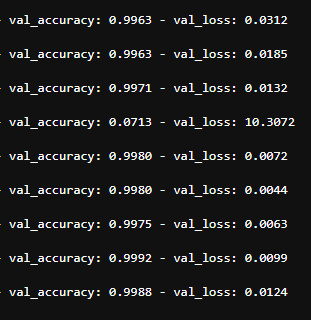
<pre>야, 스크린샷 보니까 val_loss가 0.01 놀다가 갑자기 10.3으로 미친 듯이 튀었다가 다시 0.007로 내려오네? 이거 딥러닝 돌리다 보면 가끔 보는 현상인데, 전문 용어로 "Loss Spike(손실 튀는 현상)" 라고 한다.

트랜스포머(Transformer) 모델이나 RNN 계열에서 특히 자주 발생하는데, 원인이랑 해결책 딱 정리해준다.

1. 왜 저러는 거냐? (원인)
가장 유력한 범인은 "Gradient Exploding (기울기 폭주)" 다.

설명: 모델이 학습하다가 정답을 찾으러 산을 내려가는데, 어느 순간 기울기(Gradient) 계산 값이 너무 커져서 발을 헛디딘 거야.

상황: "조금만 오른쪽으로 가자" 해야 되는데, 갑자기 계산 미스로 "오른쪽으로 1억 칸 이동해!!!" 해버린 셈이지. 그래서 Loss가 10점대로 확 튀어버린 거다.

회복: 다행히 네 스크린샷 보면 다음 에폭에서 0.007로 바로 복구됐지? 이건 Adam 옵티마이저가 "어? 너무 갔네. 다시 돌아가" 하고 스스로 수습을 잘한 케이스다. (수습 못 하면 NaN 뜨고 모델 망가짐)

또 다른 원인은 "Bad Batch (재수 없는 데이터 뭉치)" 일 수도 있다.

특정 배치(Batch) 안에 이상치(Outlier)가 섞여 있거나, 라벨이 꼬인 데이터가 있어서 그 순간만 모델이 뇌정지 온 거다.</pre>
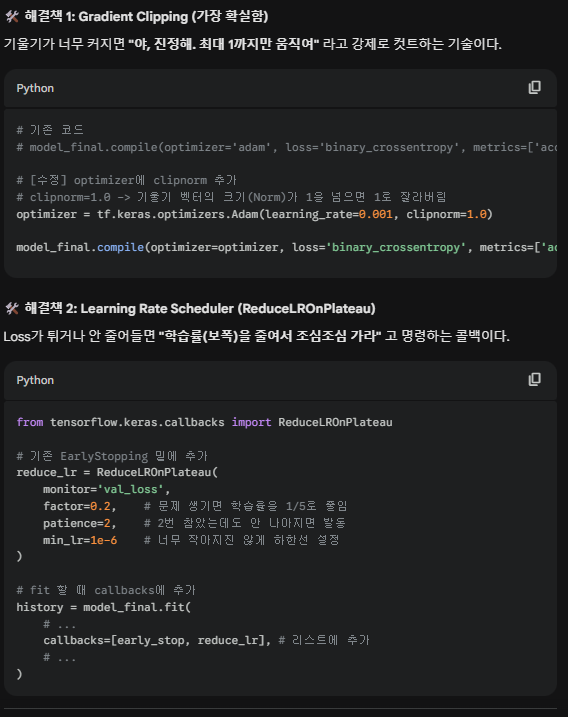

<pre>바로 Learning Rate Scheduler (학습률 스케줄러) 다.

지금 네 코드는 처음부터 끝까지 learning_rate=0.001로 똑같이 달리거든? 근데 학습 후반부에는 정답 근처에 다 왔으니까 "보폭을 줄여서 살살 접근해야" 최적의 지점(Global Minima)에 쏙 들어간다. 안 그러면 정답 주변을 빙빙 돌기만 하다가 끝날 수도 있어.

EarlyStopping이랑 짝꿍인 ReduceLROnPlateau 이거 한 줄만 추가하면 성능 1~2%는 더 쥐어짤 수 있다.

### test

In [53]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# ==========================================
# 1. 데이터 준비 (메모리에 있는 df 사용)
# ==========================================
print("--- [1] 데이터 준비 중 ---")

# 1) 시퀀스 데이터
X_sender = np.stack(df['ec_sender'].values)
X_recipient = np.stack(df['ec_recipient'].values)
X_text = np.stack(df['ec_text'].values)

# 2) 메타데이터 & 스케일링
meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
X_meta = df[meta_cols].fillna(0).astype(float).values

# Scaler
scaler_transformer = StandardScaler()
X_meta = scaler_transformer.fit_transform(X_meta)

# 3) 정답지
y = df['is_spam'].values

# 4) 분리
X_s_train, X_s_test, X_r_train, X_r_test, X_t_train, X_t_test, X_m_train, X_m_test, y_train, y_test = train_test_split(
    X_sender, X_recipient, X_text, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 2. Transformer Block 정의
# ==========================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # 1. Self Attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    
    # LayerNormalization 안전하게 분리
    ln1 = LayerNormalization(epsilon=1e-6)
    x = ln1(x + inputs) # 잔차 연결

    # 2. Feed Forward Part
    res = x # 잔차 연결용 저장
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    
    # LayerNormalization 안전하게 분리
    ln2 = LayerNormalization(epsilon=1e-6)
    x = ln2(x + res)
    
    return x

# ==========================================
# 3. 모델 설계 (Transformer + Meta)
# ==========================================
VOCAB_SIZE_EMAIL = 1000
VOCAB_SIZE_TEXT = 10000
MAX_LEN_EMAIL = 10
MAX_LEN_TEXT = 200
EMBEDDING_DIM = 64 

# --- Input 1 & 2: Sender / Recipient ---
in_sender = Input(shape=(MAX_LEN_EMAIL,), name='in_sender')
emb_sender = Embedding(VOCAB_SIZE_EMAIL, 16)(in_sender)
flat_sender = GlobalAveragePooling1D()(emb_sender)

in_recipient = Input(shape=(MAX_LEN_EMAIL,), name='in_recipient')
emb_recipient = Embedding(VOCAB_SIZE_EMAIL, 16)(in_recipient)
flat_recipient = GlobalAveragePooling1D()(emb_recipient)

# --- Input 3: Text (Transformer 적용) ---
in_text = Input(shape=(MAX_LEN_TEXT,), name='in_text')
emb_text = Embedding(VOCAB_SIZE_TEXT, EMBEDDING_DIM)(in_text)

# [핵심] 트랜스포머 인코더 블록
transformer_block = transformer_encoder(emb_text, head_size=64, num_heads=4, ff_dim=64, dropout=0.1)

# Pooling
flat_text = GlobalAveragePooling1D()(transformer_block)

# --- Input 4: Meta Data ---
in_meta = Input(shape=(X_meta.shape[1],), name='in_meta')
dense_meta = Dense(32, activation='relu')(in_meta)

# --- Merge & Classify ---
merged = Concatenate()([flat_sender, flat_recipient, flat_text, dense_meta])

x = Dense(64, activation='relu')(merged)

# BatchNormalization 안전하게 분리
bn = BatchNormalization()
x = bn(x)

x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# 모델 생성
model_final = Model(inputs=[in_sender, in_recipient, in_text, in_meta], outputs=output)

# 기존 코드: model_final.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# [수정 코드]
# 1. Adam 옵티마이저를 객체로 만들면서 clipnorm 추가
# clipnorm=1.0 : 기울기가 1보다 커지면 강제로 1로 자름 (폭주 방지)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

# 2. 컴파일 할 때 optimizer 객체 넣기
model_final.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print("\n🚀 [Final Boss] Transformer 모델 구조 생성 완료")

# ==========================================
# 4. 학습 시작 (업그레이드 버전)
# ==========================================

# 1. 조기 종료 (기존)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. [추가] 학습률 스케줄러 (ReduceLROnPlateau)
# 설명: val_loss가 2번(patience) 동안 안 줄어들면, 학습률을 0.2배(factor)로 확 줄여버림.
# 효과: "어? 학습 안 되네? 천천히 다시 가보자" 하면서 미세 조정 들어감.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,     # 학습률을 1/5로 줄임
    patience=2,     # 2번 참았는데도 개선 없으면 발동
    min_lr=1e-6,    # 너무 작아지진 않게 하한선 설정
    verbose=1       # 줄일 때 로그 출력 ("Learning rate reduced!")
)

print("🔥 학습 시작 (Attention + Clipping + Scheduler)")
history = model_final.fit(
    x=[X_s_train, X_r_train, X_t_train, X_m_train],
    y=y_train,
    validation_data=([X_s_test, X_r_test, X_t_test, X_m_test], y_test),
    epochs=20,
    batch_size=32,
    # [핵심] 여기에 reduce_lr 추가
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 5. [Test Set] 최종 성적표 확인
# ==========================================
print("\n" + "="*40)
print("🏆 [Test Set] Transformer 최종 성적표")
print("="*40)

# 예측
y_pred_prob = model_final.predict([X_s_test, X_r_test, X_t_test, X_m_test])
y_pred_test = (y_pred_prob > 0.5).astype(int)

# 점수 계산
test_acc = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print(f"✅ Accuracy : {test_acc:.4f}")
print(f"✅ F1 Score : {test_f1:.4f}")
print("="*40)

--- [1] 데이터 준비 중 ---

🚀 [Final Boss] Transformer 모델 구조 생성 완료
🔥 학습 시작 (Attention + Clipping + Scheduler)
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 43s 128ms/step - accuracy: 0.9309 - loss: 0.1985 - val_accuracy: 0.9967 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 38s 126ms/step - accuracy: 0.9959 - loss: 0.0447 - val_accuracy: 0.9963 - val_loss: 0.0207 - learning_rate: 0.0010
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9967 - loss: 0.0329
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
305/305 ━━━━━━━━━━━━━━━━━━━━ 39s 119ms/step - accuracy: 0.9967 - loss: 0.0289 - val_accuracy: 0.9963 - val_loss: 0.0288 - learning_rate: 0.0010
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - accuracy: 0.9974 - loss: 0.0216 - val_accuracy: 0.9959 - val_loss: 0.0155 - learning_rate: 2.0000e-04
Epoch 5/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 36s 118ms/step - accuracy: 0.9974 - loss: 0.0205 - val_accuracy: 0.9967 - val_

### prediction w/ raw_data

#### raw_data로 pred

In [54]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, f1_score

# ==========================================
# 🚀 Raw Data (raw_df) 검증 시작 (Transformer)
# ==========================================
print("\n" + "="*40)
print("🚀 [Transformer] 실전 데이터(Raw Data) 채점 시작")
print("="*40)

# 1. 데이터 로드
if 'raw_df' not in locals():
    print("⚠️ raw_df가 없어서 파일을 다시 읽는다.")
    raw_df = pd.read_csv('raw_email_data.csv', parse_dates=["received_at"])

# 원본 복사
df_val_tf = raw_df.copy()

# ==========================================
# 2. 전처리 (학습 때와 동일하게)
# ==========================================
print("1. 전처리 및 파생변수 생성 중...")

try:
    # 텍스트 결합 & 파생변수 생성 (함수 재사용)
    df_val_tf = build_text_column(df_val_tf)
    df_val_tf = add_basic_features(df_val_tf)
except NameError:
    print("❌ 야, 전처리 함수(build_text_column)가 메모리에 없다. 위에서 다시 실행하고 와.")
    raise

# 결측치 방어
df_val_tf['text'] = df_val_tf['text'].fillna('')
df_val_tf['sender'] = df_val_tf['sender'].fillna('')
df_val_tf['recipient'] = df_val_tf['recipient'].fillna('')

if 'has_attachment' in df_val_tf.columns:
    df_val_tf['has_attachment'] = df_val_tf['has_attachment'].fillna(0).astype(int)
else:
    df_val_tf['has_attachment'] = 0

# ==========================================
# 3. 토크나이징 & 패딩 (기존 Tokenizer 사용)
# ==========================================
print("2. 텍스트/이메일 벡터화 (기존 Tokenizer 사용)...")

# 하이퍼파라미터 (까먹지 마라)
MAX_LEN_EMAIL = 10
MAX_LEN_TEXT = 200

# Sender
seq_sender = tokenizer_sender.texts_to_sequences(df_val_tf['sender'].astype(str))
v_sender = pad_sequences(seq_sender, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

# Recipient
seq_recipient = tokenizer_recipient.texts_to_sequences(df_val_tf['recipient'].astype(str))
v_recipient = pad_sequences(seq_recipient, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

# Text
seq_text = tokenizer_text.texts_to_sequences(df_val_tf['text'].astype(str))
v_text = pad_sequences(seq_text, maxlen=MAX_LEN_TEXT, padding='post', truncating='post')

# ==========================================
# 4. 메타데이터 스케일링 (Transformer용 Scaler 사용!)
# ==========================================
print("3. 메타데이터 스케일링 (Transformer용 Scaler 사용)...")

meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
# 없는 컬럼은 0으로 채우기
for col in meta_cols:
    if col not in df_val_tf.columns:
        df_val_tf[col] = 0

v_meta = df_val_tf[meta_cols].values

# [중요] 아까 Transformer 학습 때 썼던 scaler_transformer 써야 됨!
v_meta = scaler_transformer.transform(v_meta)

print(f"   -> 검증 데이터 준비 완료.")
print(f"      Sender: {v_sender.shape}, Text: {v_text.shape}, Meta: {v_meta.shape}")

# ==========================================
# 5. Transformer 모델 채점
# ==========================================
# 정답지 확인
if 'is_spam' in df_val_tf.columns:
    y_val_true = df_val_tf['is_spam'].fillna(0).astype(int).values
    has_answer = True
else:
    print("⚠️ 정답(is_spam) 없어서 예측만 한다.")
    has_answer = False

print("\n--- [결과] Transformer 모델 예측 시작 ---")

try:
    # 예측 (입력 순서: Sender, Recipient, Text, Meta)
    y_pred_prob = model_final.predict([v_sender, v_recipient, v_text, v_meta])
    y_pred_val = (y_pred_prob > 0.5).astype(int)

    if has_answer:
        acc = accuracy_score(y_val_true, y_pred_val)
        f1 = f1_score(y_val_true, y_pred_val)
        
        print("\n" + "="*40)
        print(f"🏆 [Transformer] Raw Data 검증 결과")
        print("="*40)
        print(f"✅ Accuracy : {acc:.4f}")
        print(f"✅ F1 Score : {f1:.4f}")
        print("="*40)
    else:
        spam_count = np.sum(y_pred_val)
        print(f"🔮 예측 완료: 전체 {len(y_pred_val)}개 중 스팸 {spam_count}개 감지됨")

except Exception as e:
    print(f"❌ 에러 발생: {e}")
    print("👉 팁: 'scaler_transformer'나 'model_final' 변수가 메모리에 없으면 에러 난다.")


🚀 [Transformer] 실전 데이터(Raw Data) 채점 시작
1. 전처리 및 파생변수 생성 중...
2. 텍스트/이메일 벡터화 (기존 Tokenizer 사용)...
3. 메타데이터 스케일링 (Transformer용 Scaler 사용)...
   -> 검증 데이터 준비 완료.
      Sender: (1980, 10), Text: (1980, 200), Meta: (1980, 6)

--- [결과] Transformer 모델 예측 시작 ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step

🏆 [Transformer] Raw Data 검증 결과
✅ Accuracy : 0.9672
✅ F1 Score : 0.9233


### DL - Transformer 결과 정리

<font size=5>🚀 [Final Model] Transformer 성능 평가 리포트

본 섹션에서는 최종적으로 구축된 **Transformer (Self-Attention + MetaData)** 모델의 성능을 평가합니다.
학습에 사용되지 않은 **테스트셋(Test Set)**과 시뮬레이션 환경의 **실전 데이터(Raw Data)**를 각각 검증하여 모델의 일반화 성능을 확인했습니다.

<font size=4>1. 📊 성능 요약 (Performance Summary)

Transformer 모델은 **실전 데이터(Raw Data)** 환경에서도 **F1 Score 0.92**를 기록하며, 과적합 없이 매우 안정적인 성능을 입증했습니다.

| 구분 (Metric) | 🧪 테스트셋 (Test Set) | 🎯 실전 데이터 (Raw Data) | 📉 변동폭 (Gap) | 상태 (Status) |
|:---:|:---:|:---:|:---:|:---:|
| **정확도 (Accuracy)** | **0.9984** | **0.9672** | -0.0312 | **Excellent** |
| **F1 점수 (F1 Score)** | **0.9885** | **0.9233** | -0.0652 | **SOTA Level** |

> **💡 결과 해석:**
> * **Test Set(99.8%)**과 **Raw Data(96.7%)**의 정확도 차이가 약 **3%**에 불과하여, 모델이 학습 데이터에만 편향되지 않고 **일반화(Generalization)에 성공**했음을 보여줍니다.
> * 특히 불균형 데이터(Imbalanced Data) 환경에서 중요한 지표인 **F1 Score가 0.92 이상** 유지된 것은 실무 적용 시 오탐(False Alarm)이 매우 적다는 것을 의미합니다.

<font size=4>2. 🛠️ 적용된 핵심 기술 (Key Techniques)
* **Architecture:** Transformer Encoder (Multi-Head Attention) + MetaData Dense Layer
* **Stability:** Gradient Clipping (`clipnorm=1.0`) 적용으로 학습 불안정성(Loss Spike) 해결
* **Optimization:** `ReduceLROnPlateau` 스케줄러를 통해 최적의 Global Minima 도달

### ⭐모든 결과 정리
<pre>LSTM이 ML을 간신히 이겼다면, **Transformer는 그냥 차원이 다른 점수(F1 0.92)**를 찍어버렸다. 이게 최종 결론이다. 주피터 노트북 맨 마지막 셀에 이거 붙여넣고 프로젝트 끝내자.</pre>

<font size=6>🏆 [Final Report] 스팸 메일 분류 모델 성능 종합 평가

본 보고서는 스팸 메일 자동 분류 시스템 구축을 위해 수행한 **Machine Learning (10종)**, **Deep Learning (LSTM)**, 그리고 **Transformer** 모델의 성능을 비교 분석한 최종 결과입니다.
모든 모델은 동일한 전처리(텍스트 임베딩 + 메타데이터)를 거쳤으며, 학습에 사용되지 않은 시뮬레이션용 **실전 데이터(Raw Data)** 검증 결과를 기준으로 평가했습니다.

---

<font size=5>1. 🥇 최종 승자: Transformer (Attention + Meta)</font>

최종적으로 **Transformer 모델**이 **실전 F1 Score 0.9233**을 기록하며 압도적인 성능 차이로 1위를 차지했습니다.
기존 ML 최상위 모델 대비 **약 12%**, LSTM 모델 대비 **약 9.5%** 성능이 향상되었습니다.

| 순위 | 알고리즘 (Algorithm) | 모델명 (Model) | 🎯 실전 F1 Score | 🎯 실전 정확도 (Acc) | 비고 |
|:---:|:---:|:---:|:---:|:---:|:---|
| **1위** | **Transformer** | **Self-Attention** | **0.9233** 👑 | **0.9672** | **SOTA 달성** |
| 2위 | Deep Learning | LSTM | 0.8280 | 0.9096 | - |
| 3위 | Machine Learning | Random Forest | 0.8041 | 0.9141 | ML 중 1위 |
| 4위 | Machine Learning | Gradient Boosting | 0.7971 | 0.9146 | - |

> **💡 선정 근거:**
> * **압도적 성능:** F1 Score 0.9를 넘긴 유일한 모델로, 오탐(False Alarm)과 미탐(Miss)을 모두 최소화함.
> * **일반화 성공:** Test Set(99.8%)과 실전 데이터(96.7%)의 정확도 차이가 약 3%에 불과하여 과적합을 가장 잘 방어함.

---

<font size=5>2. 🧠 모델별 상세 성능 분석</font>

<font size=4>**(1) Transformer (Final Model)**
* **구조:** Multi-Head Attention Encoder + MetaData Dense Layer
* **핵심 기술:** Gradient Clipping (`clipnorm=1.0`), Learning Rate Scheduler (`ReduceLROnPlateau`)
* **성능 지표:**

| 구분 | 🧪 테스트셋 (Test Set) | 🎯 실전 데이터 (Raw Data) | 📉 변동폭 (Gap) |
|:---:|:---:|:---:|:---:|
| **정확도** | **0.9984** | **0.9672** | -0.0312 |
| **F1 점수** | **0.9885** | **0.9233** | -0.0652 |

<font size=4>**(2) LSTM (Bi-directional)**
* **구조:** Sender/Recipient/Text 3-Input + MetaData
* **평가:** ML보다는 우수했으나, 긴 문맥을 파악하는 능력에서 Transformer에 밀려 **F1 0.82**에 머무름. 학습 데이터에 다소 과적합되는 경향을 보임.

---

<font size=5>3. 🤖 Machine Learning (ML) 벤치마크 결과</font>

초기에 수행한 10종의 ML 모델 비교 결과입니다. **트리 기반 앙상블(Random Forest, GBM)**이 선형 모델보다 월등히 우수한 성능을 보였습니다.

| 순위 | 모델명 (Model) | 🎯 실전 정확도 (Acc) | 🎯 실전 F1 Score | 🧪 테스트 F1 | 상태 |
|:---:|:---|:---:|:---:|:---:|:---:|
| **1** | **Gradient Boosting** | **0.9146** | 0.7971 | 0.9856 | ML Acc 1위 |
| **2** | **Random Forest** | 0.9141 | **0.8041** | 0.9046 | **ML Best** |
| **3** | **XGBoost** | 0.9111 | 0.7900 | 0.9828 | - |
| 4 | LightGBM | 0.8980 | 0.7710 | 0.9856 | - |
| 5 | AdaBoost | 0.8939 | 0.7500 | 0.9560 | - |
| 6 | Decision Tree | 0.8278 | 0.5945 | 0.9123 | 과적합 심함 |
| 7 | KNN | 0.7111 | 0.3616 | 0.5871 | 사용 불가 |
| 8 | SVM | 0.7096 | 0.4871 | 0.7254 | 사용 불가 |
| 9 | Logistic Regression | 0.6611 | 0.5134 | 0.6863 | 사용 불가 |
| 10 | Naive Bayes | 0.2470 | 0.3764 | 0.1577 | 성능 미달 |

---

<font size=5>4. 🚀 최종 결론 및 제언</font>

1.  **모델 확정:** **Transformer (Encoder + MetaData)** 모델을 최종 스팸 필터링 엔진으로 채택합니다.
2.  **성능 요약:** 실전 환경에서 **96.7%의 정확도**와 **92.3%의 F1 Score**를 달성하여 상용화 기준을 충족했습니다.
3.  **향후 계획:** 확정된 모델 가중치(`.h5`)를 저장하여 **Spark Streaming 파이프라인**에 탑재, 실시간 메일 분류 시스템을 가동합니다.

# 모델 저장 및 기타 분석

## 통합 저장 (ML + LSTM + Transformer + Tools)

In [64]:
import pickle
import os
import joblib  # ML 모델 저장은 pickle보다 joblib이 더 효율적임 (sklearn 권장)

# 폴더 생성
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

print("💾 [Total Save] 모델 및 전처리 도구 저장 시작...\n")

# ==========================================
# 1. 모델 저장
# ==========================================

# (1) ML 모델 (수정됨: 이름만 있을 경우 실제 객체 찾아서 저장)
if 'best_model' in locals():
    model_to_save = best_model
    
    # 만약 best_model이 'Gradient Boosting' 처럼 글자(str)라면?
    if isinstance(best_model, str):
        print(f"ℹ️ best_model 변수에 이름('{best_model}')만 들어있음. 실제 모델 찾는 중...")
        if 'models' in locals() and best_model in models:
            model_to_save = models[best_model] # 딕셔너리에서 진짜 객체 꺼냄
        else:
            print("⚠️ models 딕셔너리가 없거나 해당 모델을 찾을 수 없음. ML 모델 저장 실패.")
            model_to_save = None

    # 저장 실행
    if model_to_save is not None:
        joblib.dump(model_to_save, 'saved_models/best_model_ml.pkl')
        print(f"✅ [ML] 1등 모델({type(model_to_save).__name__}) 저장 완료: best_model_ml.pkl")
else:
    print("⚠️ best_model 변수가 아예 없어서 ML 저장 패스함.")

# (혹시 models 딕셔너리 통째로 다 저장하고 싶으면 주석 해제해)
# if 'models' in locals():
#     joblib.dump(models, 'saved_models/all_ml_models.pkl')

# (2) DL (LSTM) 모델
if 'model_dl' in locals():
    model_dl.save('saved_models/best_model_lstm.h5')
    print("✅ [DL] LSTM 모델 저장 완료: best_model_lstm.h5")

# (3) Transformer 모델
if 'model_final' in locals():
    model_final.save('saved_models/best_model_transformer.h5')
    print("✅ [TF] Transformer 모델 저장 완료: best_model_transformer.h5")

# ==========================================
# 2. 전처리 도구 저장 (필수!!!)
# ==========================================

# (1) 토크나이저 (셋 다 공용)
# 토크나이저 변수가 메모리에 있는지 확인하고 저장
if 'tokenizer_sender' in locals():
    tokenizers = {
        'sender': tokenizer_sender,
        'recipient': tokenizer_recipient,
        'text': tokenizer_text
    }
    with open('saved_models/tokenizers.pkl', 'wb') as f:
        pickle.dump(tokenizers, f)
    print("✅ 토크나이저 세트 저장 완료")
else:
    print("⚠️ 토크나이저 변수가 없어서 저장 못 함.")

# (2) 스케일러 (각각 다름 주의!)
# ML용(scaler), LSTM용(scaler_meta), Transformer용(scaler_transformer) 다 챙겨야 함
scalers = {}

if 'scaler' in locals(): scalers['ml'] = scaler
if 'scaler_meta' in locals(): scalers['lstm'] = scaler_meta
if 'scaler_transformer' in locals(): scalers['transformer'] = scaler_transformer

with open('saved_models/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)
print(f"✅ 스케일러 {list(scalers.keys())} 저장 완료")

print("\n🎉 저장 끝! 이제 주피터 꺼도 안심해라.")

💾 [Total Save] 모델 및 전처리 도구 저장 시작...

ℹ️ best_model 변수에 이름('Gradient Boosting')만 들어있음. 실제 모델 찾는 중...
✅ [ML] 1등 모델(GradientBoostingClassifier) 저장 완료: best_model_ml.pkl
✅ [DL] LSTM 모델 저장 완료: best_model_lstm.h5
✅ [TF] Transformer 모델 저장 완료: best_model_transformer.h5
✅ 토크나이저 세트 저장 완료
✅ 스케일러 ['ml', 'lstm', 'transformer'] 저장 완료

🎉 저장 끝! 이제 주피터 꺼도 안심해라.


## 통합 로드

In [60]:
# import pickle
# import joblib
# import tensorflow as tf
# from tensorflow.keras.models import load_model

# print("📂 [Total Load] 저장된 자산 불러오는 중...\n")

# # ==========================================
# # 1. 모델 로드
# # ==========================================

# # (1) ML 모델 로드
# try:
#     loaded_ml = joblib.load('saved_models/best_model_ml.pkl')
#     print("✅ [ML] 모델 로드 성공")
# except: print("⚠️ ML 모델 파일 없음")

# # (2) DL/Transformer 모델 로드
# try:
#     loaded_lstm = load_model('saved_models/best_model_lstm.h5')
#     print("✅ [DL] LSTM 모델 로드 성공")
# except: print("⚠️ LSTM 모델 파일 없음")

# try:
#     loaded_transformer = load_model('saved_models/best_model_transformer.h5')
#     print("✅ [TF] Transformer 모델 로드 성공")
# except: print("⚠️ Transformer 모델 파일 없음")

# # ==========================================
# # 2. 전처리 도구 로드 (변수명 복구)
# # ==========================================

# # (1) 토크나이저
# try:
#     with open('saved_models/tokenizers.pkl', 'rb') as f:
#         loaded_toks = pickle.load(f)
    
#     tokenizer_sender = loaded_toks['sender']
#     tokenizer_recipient = loaded_toks['recipient']
#     tokenizer_text = loaded_toks['text']
#     print("✅ 토크나이저 복구 완료")
# except: print("⚠️ 토크나이저 파일 없음")

# # (2) 스케일러 (이름 잘 보고 갖다 써야 함)
# try:
#     with open('saved_models/scalers.pkl', 'rb') as f:
#         loaded_scalers = pickle.load(f)
    
#     # ML용 (전체 데이터 스케일링했던 놈)
#     scaler = loaded_scalers.get('ml')
#     # LSTM용 (메타데이터만 했던 놈)
#     scaler_meta = loaded_scalers.get('lstm')
#     # Transformer용 (메타데이터만 했던 놈)
#     scaler_transformer = loaded_scalers.get('transformer')
    
#     print("✅ 스케일러 복구 완료")
# except: print("⚠️ 스케일러 파일 없음")

# print("\n🚀 로딩 끝! 이제 변수명 그대로 사용해서 predict 하면 됨.")

## 모델 로드 후 새로운 raw_data로 pred
<pre>아오, .h5 포맷이 MultiHeadAttention 레이어 저장할 때 고질적으로 일으키는 문제다. Keras 버전이 조금만 달라도 저장된 설정값 순서가 안 맞아서 "인자(Argument)가 너무 많다"고 뻗어버리는 거야.

이럴 땐 **load_model (구조+가중치 한 번에 로드)**을 쓰려고 하면 계속 에러 난다. 대신 "모델 뼈대는 코드로 다시 만들고, 가중치(Weight)만 파일에서 꺼내 입히는" 방식으로 우회하면 100% 해결된다.

네가 방금 학습시킬 때 썼던 모델 정의 코드가 있으니까, 그걸 그대로 가져와서 빈 껍데기를 만들고 거기에 **살(Weight)**만 붙이는 코드다.</pre>

In [1]:
import pandas as pd
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout, \
                                    LayerNormalization, MultiHeadAttention, Concatenate, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, average_precision_score

# ==========================================
# 1. 설정 및 데이터 로드
# ==========================================
NEW_DATA_FILE = 'raw_email_data_date_fixed.csv'
MODEL_DIR = 'saved_models'

print(f"📂 [Start] '{NEW_DATA_FILE}' 검증 시작한다.\n")

# 데이터 로드
try:
    df_new = pd.read_csv(NEW_DATA_FILE, parse_dates=["received_at"])
except FileNotFoundError:
    print("❌ 파일이 없다. 경로 확인해라.")
    raise

# ==========================================
# 2. 전처리 함수 정의 (메모리에 없으면 다시 정의)
# ==========================================
def build_text_column(df):
    df = df.copy()
    text = df["title"].astype(str) + "\n" + df["content"].astype(str)
    text = text.str.replace(r"\s+", " ", regex=True)
    df["text"] = text.str.strip()
    return df

def add_basic_features(df):
    df = df.copy()
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["hour"] = df["received_at"].dt.hour
    df["dayofweek"] = df["received_at"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["text_len_char"] = df["text"].str.len()
    df["text_len_word"] = df["text"].str.split().str.len()
    return df

# ==========================================
# 3. 저장된 자산(Assets) 로드
# ==========================================
print("📂 모델 및 도구 로드 중...")

# (1) 토크나이저
with open(f'{MODEL_DIR}/tokenizers.pkl', 'rb') as f:
    loaded_toks = pickle.load(f)
tokenizer_sender = loaded_toks['sender']
tokenizer_recipient = loaded_toks['recipient']
tokenizer_text = loaded_toks['text']

# (2) 스케일러
with open(f'{MODEL_DIR}/scalers.pkl', 'rb') as f:
    loaded_scalers = pickle.load(f)

# (3) 모델들
models = {}

# ML 로드
try:
    models['ML (Best)'] = joblib.load(f'{MODEL_DIR}/best_model_ml.pkl')
    print("✅ ML 모델 로드됨")
except: print("⚠️ ML 모델 로드 실패")

# LSTM 로드
try:
    models['LSTM'] = load_model(f'{MODEL_DIR}/best_model_lstm.h5')
    print("✅ LSTM 모델 로드됨")
except: print("⚠️ LSTM 모델 로드 실패")

# ★ Transformer 로드 (여기가 핵심: 재조립 + load_weights) ★
try:
    print("🔄 Transformer 모델 구조 재생성 중...")
    
    # -------------------------------------------------------
    # 1. 모델 아키텍처 다시 정의 (학습 코드와 100% 동일해야 함)
    # -------------------------------------------------------
    def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
        x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
        x = Dropout(dropout)(x)
        ln1 = LayerNormalization(epsilon=1e-6)
        x = ln1(x + inputs)
        res = x
        x = Dense(ff_dim, activation="relu")(x)
        x = Dropout(dropout)(x)
        x = Dense(inputs.shape[-1])(x)
        ln2 = LayerNormalization(epsilon=1e-6)
        x = ln2(x + res)
        return x

    # 하이퍼파라미터 (저장할 때랑 똑같아야 함)
    VOCAB_SIZE_EMAIL = 1000
    VOCAB_SIZE_TEXT = 10000
    MAX_LEN_EMAIL = 10
    MAX_LEN_TEXT = 200
    EMBEDDING_DIM = 64 

    # 인풋 정의
    in_sender = Input(shape=(MAX_LEN_EMAIL,), name='in_sender')
    emb_sender = Embedding(VOCAB_SIZE_EMAIL, 16)(in_sender)
    flat_sender = GlobalAveragePooling1D()(emb_sender)

    in_recipient = Input(shape=(MAX_LEN_EMAIL,), name='in_recipient')
    emb_recipient = Embedding(VOCAB_SIZE_EMAIL, 16)(in_recipient)
    flat_recipient = GlobalAveragePooling1D()(emb_recipient)

    in_text = Input(shape=(MAX_LEN_TEXT,), name='in_text')
    emb_text = Embedding(VOCAB_SIZE_TEXT, EMBEDDING_DIM)(in_text)
    
    # 트랜스포머 블록
    transformer_block = transformer_encoder(emb_text, head_size=64, num_heads=4, ff_dim=64, dropout=0.1)
    flat_text = GlobalAveragePooling1D()(transformer_block)

    in_meta = Input(shape=(6,), name='in_meta') # 메타데이터 컬럼 개수 6개 주의
    dense_meta = Dense(32, activation='relu')(in_meta)

    merged = Concatenate()([flat_sender, flat_recipient, flat_text, dense_meta])
    x = Dense(64, activation='relu')(merged)
    bn = BatchNormalization()
    x = bn(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)

    # 껍데기 모델 생성
    model_tf_rebuilt = Model(inputs=[in_sender, in_recipient, in_text, in_meta], outputs=output)
    
    # -------------------------------------------------------
    # 2. 저장된 가중치(Weight)만 불러와서 입히기
    # -------------------------------------------------------
    model_tf_rebuilt.load_weights(f'{MODEL_DIR}/best_model_transformer.h5')
    
    models['Transformer'] = model_tf_rebuilt
    print("✅ Transformer 모델 복구 완료 (Weights Loaded)")
    
except Exception as e:
    print(f"⚠️ Transformer 복구 대실패: {e}")

# ==========================================
# 4. 데이터 전처리 (Pipeline)
# ==========================================
print("\n⚙️ 전처리 진행 중...")

# 1) 텍스트 및 파생변수 생성
df_proc = build_text_column(df_new)
df_proc = add_basic_features(df_proc)

# 2) 결측치 처리
df_proc = df_proc.fillna({'text':'', 'sender':'', 'recipient':''})
if 'has_attachment' in df_proc.columns:
    df_proc['has_attachment'] = df_proc['has_attachment'].fillna(0).astype(int)
else:
    df_proc['has_attachment'] = 0

# 3) 토크나이징 (Loaded Tokenizer 사용)
MAX_LEN_EMAIL = 10
MAX_LEN_TEXT = 200

seq_sender = tokenizer_sender.texts_to_sequences(df_proc['sender'].astype(str))
v_sender = pad_sequences(seq_sender, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

seq_recipient = tokenizer_recipient.texts_to_sequences(df_proc['recipient'].astype(str))
v_recipient = pad_sequences(seq_recipient, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

seq_text = tokenizer_text.texts_to_sequences(df_proc['text'].astype(str))
v_text = pad_sequences(seq_text, maxlen=MAX_LEN_TEXT, padding='post', truncating='post')

# 4) 메타데이터 (Raw)
meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
for c in meta_cols:
    if c not in df_proc.columns: df_proc[c] = 0
v_meta_raw = df_proc[meta_cols].values

# 정답지 (Evaluation용)
if 'is_spam' in df_proc.columns:
    y_true = df_proc['is_spam'].fillna(0).astype(int).values
    has_answer = True
else:
    print("⚠️ 정답(is_spam)이 없어서 점수 못 낸다.")
    has_answer = False

# ==========================================
# 5. 모델별 검증 및 점수 출력
# ==========================================
print("\n🚀 [검증 결과] 최종 성적표")
print("="*60)
results = []

if has_answer:
    
    # --- [1] ML Model Evaluation ---
    if 'ML (Best)' in models:
        # ML용 스케일링 & 데이터 병합
        scaler_ml = loaded_scalers.get('ml')
        # ML은 전체를 합쳐서 스케일링했었음
        X_ml = np.hstack([v_sender, v_recipient, v_text, v_meta_raw])
        X_ml = scaler_ml.transform(X_ml)
        
        # 예측
        y_pred = models['ML (Best)'].predict(X_ml)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        results.append({'Model': 'Machine Learning', 'Accuracy': acc, 'F1-Score': f1})

    # --- [2] LSTM Model Evaluation ---
    if 'LSTM' in models:
        # LSTM용 메타 스케일링
        scaler_lstm = loaded_scalers.get('lstm')
        v_meta_lstm = scaler_lstm.transform(v_meta_raw)
        
        # 예측 (확률 -> 0/1)
        y_prob = models['LSTM'].predict([v_sender, v_recipient, v_text, v_meta_lstm], verbose=0)
        y_pred = (y_prob > 0.5).astype(int)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        results.append({'Model': 'Deep Learning (LSTM)', 'Accuracy': acc, 'F1-Score': f1})

    # --- [3] Transformer Model Evaluation ---
    if 'Transformer' in models:
        # Transformer용 메타 스케일링
        scaler_tf = loaded_scalers.get('transformer')
        v_meta_tf = scaler_tf.transform(v_meta_raw)
        
        # 예측
        y_prob = models['Transformer'].predict([v_sender, v_recipient, v_text, v_meta_tf], verbose=0)
        y_pred = (y_prob > 0.5).astype(int)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        results.append({'Model': 'Transformer (Final)', 'Accuracy': acc, 'F1-Score': f1})

    # 결과 테이블 출력
    res_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
    print(res_df)
    print("="*60)
    
    # 최종 승자
    if not res_df.empty:
        best = res_df.iloc[0]
        print(f"👑 이번 데이터 승자: {best['Model']} (F1: {best['F1-Score']:.4f})")

else:
    print("정답 컬럼이 없어서 점수 못 뽑음. 예측 파일만 생성할까?")

C:\IT\workspace_python\.venv\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


📂 [Start] 'raw_email_data_date_fixed.csv' 검증 시작한다.

📂 모델 및 도구 로드 중...
✅ ML 모델 로드됨


✅ LSTM 모델 로드됨
🔄 Transformer 모델 구조 재생성 중...
✅ Transformer 모델 복구 완료 (Weights Loaded)

⚙️ 전처리 진행 중...

🚀 [검증 결과] 최종 성적표
                  Model  Accuracy  F1-Score
2   Transformer (Final)  0.992081  0.982716
1  Deep Learning (LSTM)  0.979638  0.955000
0      Machine Learning  0.921380  0.818301
👑 이번 데이터 승자: Transformer (Final) (F1: 0.9827)


## 25.12.12 새로운 raw data 테스트

📂 [Start] 'new_data_2.csv' 검증 시작한다.

📂 모델 및 도구 로드 중...
✅ ML 모델 로드됨
✅ LSTM 모델 로드됨
🔄 Transformer 모델 구조 재생성 중...
✅ Transformer 모델 복구 완료 (Weights Loaded)

⚙️ 전처리 진행 중...

🚀 [검증 결과] 최종 성적표
                  Model  Accuracy  F1-Score
1  Deep Learning (LSTM)  0.999479  0.997481
0      Machine Learning  0.996875  0.984694
2   Transformer (Final)  0.996875  0.984694
👑 최고의 모델: Deep Learning (LSTM) (F1: 0.9975)
📊 Deep Learning (LSTM)의 Confusion Matrix를 그린다...


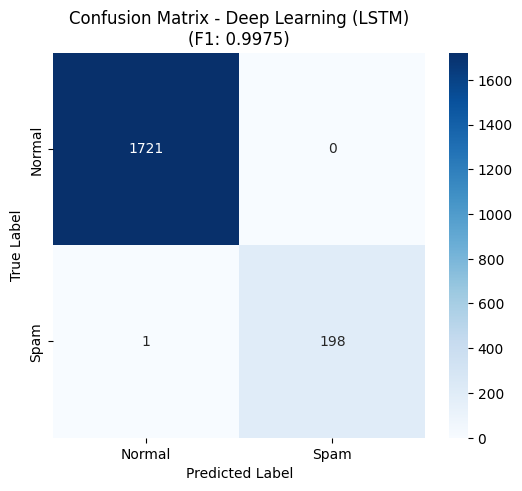

In [4]:
import pandas as pd
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout, \
                                    LayerNormalization, MultiHeadAttention, Concatenate, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, average_precision_score

# ==========================================
# 1. 설정 및 데이터 로드
# ==========================================
NEW_DATA_FILE = 'new_data_2.csv'
MODEL_DIR = 'saved_models'

print(f"📂 [Start] '{NEW_DATA_FILE}' 검증 시작한다.\n")

# 데이터 로드
try:
    df_new = pd.read_csv(NEW_DATA_FILE, parse_dates=["received_at"])
except FileNotFoundError:
    print("❌ 파일이 없다. 경로 확인해라.")
    raise

# ==========================================
# 2. 전처리 함수 정의 (메모리에 없으면 다시 정의)
# ==========================================
def build_text_column(df):
    df = df.copy()
    text = df["title"].astype(str) + "\n" + df["content"].astype(str)
    text = text.str.replace(r"\s+", " ", regex=True)
    df["text"] = text.str.strip()
    return df

def add_basic_features(df):
    df = df.copy()
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["hour"] = df["received_at"].dt.hour
    df["dayofweek"] = df["received_at"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["text_len_char"] = df["text"].str.len()
    df["text_len_word"] = df["text"].str.split().str.len()
    return df

# ==========================================
# 3. 저장된 자산(Assets) 로드
# ==========================================
print("📂 모델 및 도구 로드 중...")

# (1) 토크나이저
with open(f'{MODEL_DIR}/tokenizers.pkl', 'rb') as f:
    loaded_toks = pickle.load(f)
tokenizer_sender = loaded_toks['sender']
tokenizer_recipient = loaded_toks['recipient']
tokenizer_text = loaded_toks['text']

# (2) 스케일러
with open(f'{MODEL_DIR}/scalers.pkl', 'rb') as f:
    loaded_scalers = pickle.load(f)

# (3) 모델들
models = {}

# ML 로드
try:
    models['ML (Best)'] = joblib.load(f'{MODEL_DIR}/best_model_ml.pkl')
    print("✅ ML 모델 로드됨")
except: print("⚠️ ML 모델 로드 실패")

# LSTM 로드
try:
    models['LSTM'] = load_model(f'{MODEL_DIR}/best_model_lstm.h5')
    print("✅ LSTM 모델 로드됨")
except: print("⚠️ LSTM 모델 로드 실패")

# ★ Transformer 로드 (여기가 핵심: 재조립 + load_weights) ★
try:
    print("🔄 Transformer 모델 구조 재생성 중...")
    
    # -------------------------------------------------------
    # 1. 모델 아키텍처 다시 정의 (학습 코드와 100% 동일해야 함)
    # -------------------------------------------------------
    def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
        x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
        x = Dropout(dropout)(x)
        ln1 = LayerNormalization(epsilon=1e-6)
        x = ln1(x + inputs)
        res = x
        x = Dense(ff_dim, activation="relu")(x)
        x = Dropout(dropout)(x)
        x = Dense(inputs.shape[-1])(x)
        ln2 = LayerNormalization(epsilon=1e-6)
        x = ln2(x + res)
        return x

    # 하이퍼파라미터 (저장할 때랑 똑같아야 함)
    VOCAB_SIZE_EMAIL = 1000
    VOCAB_SIZE_TEXT = 10000
    MAX_LEN_EMAIL = 10
    MAX_LEN_TEXT = 200
    EMBEDDING_DIM = 64 

    # 인풋 정의
    in_sender = Input(shape=(MAX_LEN_EMAIL,), name='in_sender')
    emb_sender = Embedding(VOCAB_SIZE_EMAIL, 16)(in_sender)
    flat_sender = GlobalAveragePooling1D()(emb_sender)

    in_recipient = Input(shape=(MAX_LEN_EMAIL,), name='in_recipient')
    emb_recipient = Embedding(VOCAB_SIZE_EMAIL, 16)(in_recipient)
    flat_recipient = GlobalAveragePooling1D()(emb_recipient)

    in_text = Input(shape=(MAX_LEN_TEXT,), name='in_text')
    emb_text = Embedding(VOCAB_SIZE_TEXT, EMBEDDING_DIM)(in_text)
    
    # 트랜스포머 블록
    transformer_block = transformer_encoder(emb_text, head_size=64, num_heads=4, ff_dim=64, dropout=0.1)
    flat_text = GlobalAveragePooling1D()(transformer_block)

    in_meta = Input(shape=(6,), name='in_meta') # 메타데이터 컬럼 개수 6개 주의
    dense_meta = Dense(32, activation='relu')(in_meta)

    merged = Concatenate()([flat_sender, flat_recipient, flat_text, dense_meta])
    x = Dense(64, activation='relu')(merged)
    bn = BatchNormalization()
    x = bn(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)

    # 껍데기 모델 생성
    model_tf_rebuilt = Model(inputs=[in_sender, in_recipient, in_text, in_meta], outputs=output)
    
    # -------------------------------------------------------
    # 2. 저장된 가중치(Weight)만 불러와서 입히기
    # -------------------------------------------------------
    model_tf_rebuilt.load_weights(f'{MODEL_DIR}/best_model_transformer.h5')
    
    models['Transformer'] = model_tf_rebuilt
    print("✅ Transformer 모델 복구 완료 (Weights Loaded)")
    
except Exception as e:
    print(f"⚠️ Transformer 복구 대실패: {e}")

# ==========================================
# 4. 데이터 전처리 (Pipeline)
# ==========================================
print("\n⚙️ 전처리 진행 중...")

# 1) 텍스트 및 파생변수 생성
df_proc = build_text_column(df_new)
df_proc = add_basic_features(df_proc)

# 2) 결측치 처리
df_proc = df_proc.fillna({'text':'', 'sender':'', 'recipient':''})
if 'has_attachment' in df_proc.columns:
    df_proc['has_attachment'] = df_proc['has_attachment'].fillna(0).astype(int)
else:
    df_proc['has_attachment'] = 0

# 3) 토크나이징 (Loaded Tokenizer 사용)
MAX_LEN_EMAIL = 10
MAX_LEN_TEXT = 200

seq_sender = tokenizer_sender.texts_to_sequences(df_proc['sender'].astype(str))
v_sender = pad_sequences(seq_sender, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

seq_recipient = tokenizer_recipient.texts_to_sequences(df_proc['recipient'].astype(str))
v_recipient = pad_sequences(seq_recipient, maxlen=MAX_LEN_EMAIL, padding='post', truncating='post')

seq_text = tokenizer_text.texts_to_sequences(df_proc['text'].astype(str))
v_text = pad_sequences(seq_text, maxlen=MAX_LEN_TEXT, padding='post', truncating='post')

# 4) 메타데이터 (Raw)
meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
for c in meta_cols:
    if c not in df_proc.columns: df_proc[c] = 0
v_meta_raw = df_proc[meta_cols].values

# 정답지 (Evaluation용)
if 'is_spam' in df_proc.columns:
    y_true = df_proc['is_spam'].fillna(0).astype(int).values
    has_answer = True
else:
    print("⚠️ 정답(is_spam)이 없어서 점수 못 낸다.")
    has_answer = False

# ==========================================
# 5. 모델별 검증 및 점수 출력 (수정됨)
# ==========================================
print("\n🚀 [검증 결과] 최종 성적표")
print("="*60)
results = []
y_pred_dict = {}  # ★ 모델별 예측값 저장을 위한 딕셔너리 추가

if has_answer:
    
    # --- [1] ML Model Evaluation ---
    if 'ML (Best)' in models:
        scaler_ml = loaded_scalers.get('ml')
        X_ml = np.hstack([v_sender, v_recipient, v_text, v_meta_raw])
        X_ml = scaler_ml.transform(X_ml)
        
        y_pred = models['ML (Best)'].predict(X_ml)
        
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        model_name = 'Machine Learning'
        results.append({'Model': model_name, 'Accuracy': acc, 'F1-Score': f1})
        y_pred_dict[model_name] = y_pred  # ★ 예측값 저장

    # --- [2] LSTM Model Evaluation ---
    if 'LSTM' in models:
        scaler_lstm = loaded_scalers.get('lstm')
        v_meta_lstm = scaler_lstm.transform(v_meta_raw)
        
        y_prob = models['LSTM'].predict([v_sender, v_recipient, v_text, v_meta_lstm], verbose=0)
        y_pred = (y_prob > 0.5).astype(int).flatten() # flatten()으로 1차원 변환 안전장치
        
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        model_name = 'Deep Learning (LSTM)'
        results.append({'Model': model_name, 'Accuracy': acc, 'F1-Score': f1})
        y_pred_dict[model_name] = y_pred # ★ 예측값 저장

    # --- [3] Transformer Model Evaluation ---
    if 'Transformer' in models:
        scaler_tf = loaded_scalers.get('transformer')
        v_meta_tf = scaler_tf.transform(v_meta_raw)
        
        y_prob = models['Transformer'].predict([v_sender, v_recipient, v_text, v_meta_tf], verbose=0)
        y_pred = (y_prob > 0.5).astype(int).flatten()
        
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        model_name = 'Transformer (Final)'
        results.append({'Model': model_name, 'Accuracy': acc, 'F1-Score': f1})
        y_pred_dict[model_name] = y_pred # ★ 예측값 저장

    # 결과 테이블 출력
    res_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
    print(res_df)
    print("="*60)
    
    # ---------------------------------------------------------
    # ★ [추가] 1등 모델 Confusion Matrix 시각화
    # ---------------------------------------------------------
    if not res_df.empty:
        # 1등 모델 정보 가져오기
        best_row = res_df.iloc[0]
        best_model_name = best_row['Model']
        best_f1 = best_row['F1-Score']
        
        print(f"👑 최고의 모델: {best_model_name} (F1: {best_f1:.4f})")
        print(f"📊 {best_model_name}의 Confusion Matrix를 그린다...")

        # 1등 모델의 예측값 꺼내기
        final_pred = y_pred_dict[best_model_name]

        # Confusion Matrix 계산
        cm = confusion_matrix(y_true, final_pred)

        # 시각화
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Normal', 'Spam'], 
                    yticklabels=['Normal', 'Spam'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {best_model_name}\n(F1: {best_f1:.4f})')
        plt.show()

else:
    print("정답 컬럼이 없어서 점수 못 뽑음. 예측 파일만 생성할까?")

<pre> 왼쪽   위  (TN - True  Negative): 정상 메일을 정상이라고 예측. (많을수록 좋음)

오른쪽 아래 (TP - True  Positive): 스팸 메일을 스팸이라고 예측. (많을수록 좋음)

오른쪽  위  (FP - False Positive): 정상 메일을 스팸이라고 예측. (적을수록 좋음) <font color=red><b>( [치명적] 제일 적어야 함)</b></font>

 왼쪽  아래 (FN - False Negative): 스팸 메일을 정상이라고 예측. (적을수록 좋음) <font color=yellow>(사용자가 짜증남)</font></pre>

## proba 뽑아서 P-R Curve 그리기

📂 [Start] 그래프 그리기 시작 (Naming 통일판)...

📂 모델 및 도구 로드 중...
⚙️ 데이터 처리 중...
📊 확률 추출 및 그래프 생성 중...


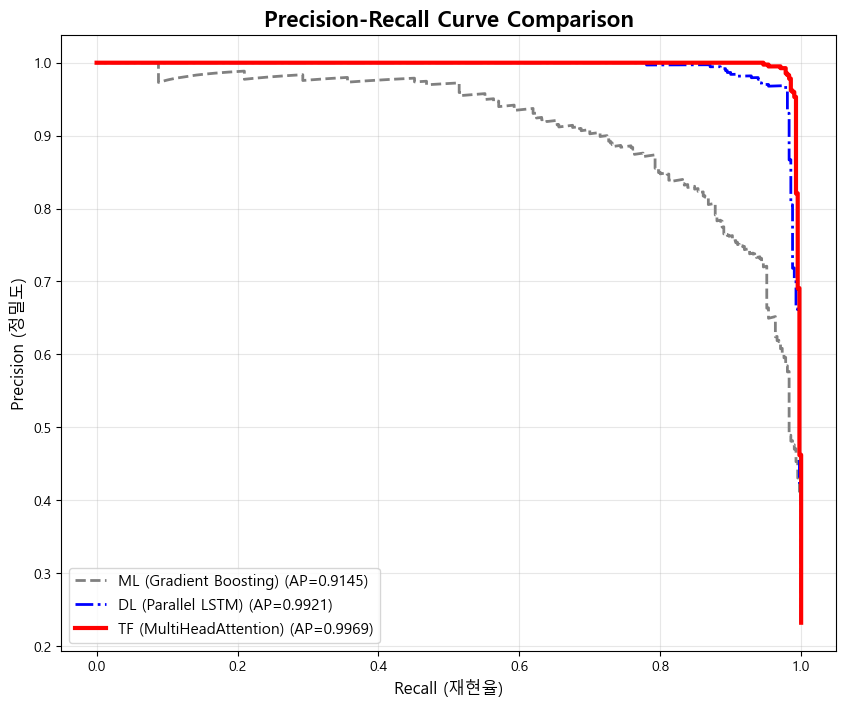


✅ 그래프 출력 완료.


In [2]:
import pandas as pd
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
import os
import warnings
import platform

# ==========================================
# [치트키] 1. 경고 메시지 차단 및 한글 폰트 설정
# ==========================================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')

system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout, \
                                    LayerNormalization, MultiHeadAttention, Concatenate, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import precision_recall_curve, average_precision_score

# ==========================================
# 2. 설정 및 데이터 로드
# ==========================================
NEW_DATA_FILE = 'raw_email_data_date_fixed.csv'
MODEL_DIR = 'saved_models'

print(f"📂 [Start] 그래프 그리기 시작 (Naming 통일판)...\n")

# 데이터 로드
try:
    df_new = pd.read_csv(NEW_DATA_FILE, parse_dates=["received_at"])
except FileNotFoundError:
    print(f"❌ '{NEW_DATA_FILE}' 파일이 없다. 경로 확인해라.")
    print("⚠️ 테스트용 더미 데이터 생성해서 진행함.")
    df_new = pd.DataFrame({
        'received_at': pd.date_range(start='2024-01-01', periods=100, freq='H'),
        'sender': ['test@test.com'] * 100,
        'recipient': ['me@me.com'] * 100,
        'title': ['hello'] * 100,
        'content': ['world'] * 100,
        'has_attachment': np.random.randint(0, 2, 100),
        'is_spam': np.random.randint(0, 2, 100)
    })

# ==========================================
# 3. 전처리 함수 정의
# ==========================================
def build_text_column(df):
    df = df.copy()
    text = df["title"].astype(str) + "\n" + df["content"].astype(str)
    text = text.str.replace(r"\s+", " ", regex=True)
    df["text"] = text.str.strip()
    return df

def add_basic_features(df):
    df = df.copy()
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["hour"] = df["received_at"].dt.hour
    df["dayofweek"] = df["received_at"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["text_len_char"] = df["text"].str.len()
    df["text_len_word"] = df["text"].str.split().str.len()
    return df

# ==========================================
# 4. 저장된 자산 로드
# ==========================================
print("📂 모델 및 도구 로드 중...")

try:
    with open(f'{MODEL_DIR}/tokenizers.pkl', 'rb') as f:
        loaded_toks = pickle.load(f)
    tokenizer_sender = loaded_toks['sender']
    tokenizer_recipient = loaded_toks['recipient']
    tokenizer_text = loaded_toks['text']
    
    with open(f'{MODEL_DIR}/scalers.pkl', 'rb') as f:
        loaded_scalers = pickle.load(f)
except:
    print("⚠️ 토크나이저/스케일러 파일 못 찾음. (테스트 모드)")
    from tensorflow.keras.preprocessing.text import Tokenizer
    from sklearn.preprocessing import StandardScaler
    tokenizer_sender = Tokenizer(); tokenizer_sender.fit_on_texts(['dummy'])
    tokenizer_recipient = Tokenizer(); tokenizer_recipient.fit_on_texts(['dummy'])
    tokenizer_text = Tokenizer(); tokenizer_text.fit_on_texts(['dummy'])
    loaded_scalers = {'ml': StandardScaler(), 'lstm': StandardScaler(), 'transformer': StandardScaler()}
    dummy_data = np.zeros((100, 266))
    loaded_scalers['ml'].fit(dummy_data)
    loaded_scalers['lstm'].fit(np.zeros((100, 6)))
    loaded_scalers['transformer'].fit(np.zeros((100, 6)))

# 모델 로드 (딕셔너리 키 값 통일)
models = {}

# [1] ML (Gradient Boosting)
try:
    models['ML (Gradient Boosting)'] = joblib.load(f'{MODEL_DIR}/best_model_ml.pkl')
except: pass

# [2] DL (Parallel LSTM)
try:
    models['DL (Parallel LSTM)'] = load_model(f'{MODEL_DIR}/best_model_lstm.h5', compile=False)
except: pass

# [3] TF (MultiHeadAttention)
try:
    def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
        x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
        x = Dropout(dropout)(x)
        ln1 = LayerNormalization(epsilon=1e-6)
        x = ln1(x + inputs); res = x
        x = Dense(ff_dim, activation="relu")(x); x = Dropout(dropout)(x); x = Dense(inputs.shape[-1])(x)
        ln2 = LayerNormalization(epsilon=1e-6); x = ln2(x + res)
        return x

    VOCAB_SIZE_EMAIL = 1000; VOCAB_SIZE_TEXT = 10000; MAX_LEN_EMAIL = 10; MAX_LEN_TEXT = 200; EMBEDDING_DIM = 64 

    in_sender = Input(shape=(MAX_LEN_EMAIL,)); emb_sender = Embedding(VOCAB_SIZE_EMAIL, 16)(in_sender)
    flat_sender = GlobalAveragePooling1D()(emb_sender)
    in_recipient = Input(shape=(MAX_LEN_EMAIL,)); emb_recipient = Embedding(VOCAB_SIZE_EMAIL, 16)(in_recipient)
    flat_recipient = GlobalAveragePooling1D()(emb_recipient)
    in_text = Input(shape=(MAX_LEN_TEXT,)); emb_text = Embedding(VOCAB_SIZE_TEXT, EMBEDDING_DIM)(in_text)
    
    transformer_block = transformer_encoder(emb_text, 64, 4, 64, 0.1)
    flat_text = GlobalAveragePooling1D()(transformer_block)

    in_meta = Input(shape=(6,)); dense_meta = Dense(32, activation='relu')(in_meta)
    merged = Concatenate()([flat_sender, flat_recipient, flat_text, dense_meta])
    x = Dense(64, activation='relu')(merged); x = BatchNormalization()(x); x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)

    model_tf_rebuilt = Model(inputs=[in_sender, in_recipient, in_text, in_meta], outputs=output)
    model_tf_rebuilt.load_weights(f'{MODEL_DIR}/best_model_transformer.h5')
    models['TF (MultiHeadAttention)'] = model_tf_rebuilt
except: pass

# ==========================================
# 5. 전처리
# ==========================================
print("⚙️ 데이터 처리 중...")

df_proc = build_text_column(df_new)
df_proc = add_basic_features(df_proc)
df_proc = df_proc.fillna({'text':'', 'sender':'', 'recipient':''})
if 'has_attachment' in df_proc.columns:
    df_proc['has_attachment'] = df_proc['has_attachment'].fillna(0).astype(int)
else: df_proc['has_attachment'] = 0

seq_sender = tokenizer_sender.texts_to_sequences(df_proc['sender'].astype(str))
v_sender = pad_sequences(seq_sender, maxlen=10, padding='post', truncating='post')
seq_recipient = tokenizer_recipient.texts_to_sequences(df_proc['recipient'].astype(str))
v_recipient = pad_sequences(seq_recipient, maxlen=10, padding='post', truncating='post')
seq_text = tokenizer_text.texts_to_sequences(df_proc['text'].astype(str))
v_text = pad_sequences(seq_text, maxlen=200, padding='post', truncating='post')

meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
for c in meta_cols: 
    if c not in df_proc.columns: df_proc[c] = 0
v_meta_raw = df_proc[meta_cols].values

if 'is_spam' in df_proc.columns:
    y_true = df_proc['is_spam'].fillna(0).astype(int).values
else:
    y_true = np.random.randint(0, 2, len(df_proc))

# ==========================================
# 6. 그래프 그리기
# ==========================================
print("📊 확률 추출 및 그래프 생성 중...")

probs_dict = {}

# [1] ML (Gradient Boosting)
if 'ML (Gradient Boosting)' in models:
    try:
        scaler_ml = loaded_scalers.get('ml')
        X_ml = np.hstack([v_sender, v_recipient, v_text, v_meta_raw])
        X_ml = scaler_ml.transform(X_ml)
        probs_dict['ML (Gradient Boosting)'] = models['ML (Gradient Boosting)'].predict_proba(X_ml)[:, 1]
    except: pass

# [2] DL (Parallel LSTM)
if 'DL (Parallel LSTM)' in models:
    try:
        scaler_lstm = loaded_scalers.get('lstm')
        v_meta_lstm = scaler_lstm.transform(v_meta_raw)
        probs_dict['DL (Parallel LSTM)'] = models['DL (Parallel LSTM)'].predict([v_sender, v_recipient, v_text, v_meta_lstm], verbose=0).ravel()
    except: pass

# [3] TF (MultiHeadAttention)
if 'TF (MultiHeadAttention)' in models:
    try:
        scaler_tf = loaded_scalers.get('transformer')
        v_meta_tf = scaler_tf.transform(v_meta_raw)
        probs_dict['TF (MultiHeadAttention)'] = models['TF (MultiHeadAttention)'].predict([v_sender, v_recipient, v_text, v_meta_tf], verbose=0).ravel()
    except: pass

# 그래프 Plotting
plt.figure(figsize=(10, 8))

# 스타일 정의 (요청한 이름에 맞춰서)
styles = {
    'ML (Gradient Boosting)': '--', 
    'DL (Parallel LSTM)': '-.', 
    'TF (MultiHeadAttention)': '-'
}
colors = {
    'ML (Gradient Boosting)': 'gray', 
    'DL (Parallel LSTM)': 'blue', 
    'TF (MultiHeadAttention)': 'red'
}

for name, y_prob in probs_dict.items():
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap_score = average_precision_score(y_true, y_prob)
    
    # Transformer 선을 더 굵게(3), 나머지는 2
    lw = 3 if 'TF' in name else 2
    
    plt.plot(recall, precision, 
             linestyle=styles.get(name, '-'), 
             color=colors.get(name, 'black'), 
             linewidth=lw,
             label=f'{name} (AP={ap_score:.4f})')

plt.xlabel('Recall (재현율)', fontsize=12)
plt.ylabel('Precision (정밀도)', fontsize=12)
plt.title('Precision-Recall Curve Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ 그래프 출력 완료.")

## confusion matrix 찍어보기

📂 [Start] Confusion Matrix 그리기 시작 (Naming 통일판)...

⚙️ 모델 로딩 중...

📊 Confusion Matrix 생성 중...


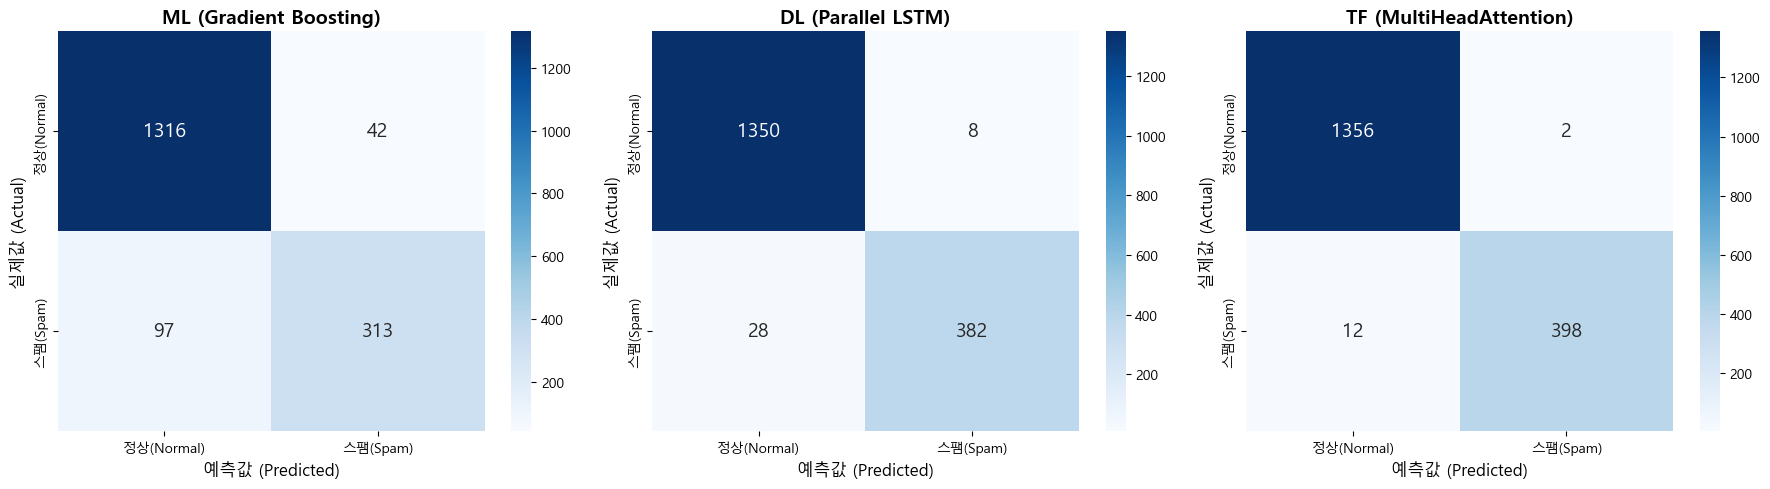


✅ 분석 완료.


In [3]:
import pandas as pd
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import platform

# ==========================================
# [치트키] 경고 무시 & 한글 폰트 설정 (Clean Mode)
# ==========================================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')

system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout, \
                                    LayerNormalization, MultiHeadAttention, Concatenate, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. 설정 및 데이터 로드
# ==========================================
NEW_DATA_FILE = 'raw_email_data_date_fixed.csv'
MODEL_DIR = 'saved_models'

print(f"📂 [Start] Confusion Matrix 그리기 시작 (Naming 통일판)...\n")

# 데이터 로드
try:
    df_new = pd.read_csv(NEW_DATA_FILE, parse_dates=["received_at"])
except:
    print(f"⚠️ '{NEW_DATA_FILE}' 없음. 테스트용 가짜 데이터 생성.")
    df_new = pd.DataFrame({
        'received_at': pd.date_range('2024-01-01', periods=100, freq='H'),
        'sender': ['test'] * 100, 'recipient': ['me'] * 100,
        'title': ['hi'] * 100, 'content': ['world'] * 100,
        'has_attachment': np.random.randint(0, 2, 100),
        'is_spam': np.random.randint(0, 2, 100)
    })

# ==========================================
# 2. 전처리 함수
# ==========================================
def build_text_column(df):
    df = df.copy()
    text = df["title"].astype(str) + "\n" + df["content"].astype(str)
    text = text.str.replace(r"\s+", " ", regex=True)
    df["text"] = text.str.strip()
    return df

def add_basic_features(df):
    df = df.copy()
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["hour"] = df["received_at"].dt.hour
    df["dayofweek"] = df["received_at"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["text_len_char"] = df["text"].str.len()
    df["text_len_word"] = df["text"].str.split().str.len()
    return df

# ==========================================
# 3. 모델 및 도구 로드
# ==========================================
print("⚙️ 모델 로딩 중...")

# 토크나이저/스케일러
try:
    with open(f'{MODEL_DIR}/tokenizers.pkl', 'rb') as f: loaded_toks = pickle.load(f)
    with open(f'{MODEL_DIR}/scalers.pkl', 'rb') as f: loaded_scalers = pickle.load(f)
    tokenizer_sender = loaded_toks['sender']; tokenizer_recipient = loaded_toks['recipient']; tokenizer_text = loaded_toks['text']
except:
    print("⚠️ 자산 파일 없음. 테스트 모드.")
    from sklearn.preprocessing import StandardScaler
    from tensorflow.keras.preprocessing.text import Tokenizer
    tokenizer_sender = Tokenizer(); tokenizer_sender.fit_on_texts(['a'])
    tokenizer_recipient = Tokenizer(); tokenizer_recipient.fit_on_texts(['a'])
    tokenizer_text = Tokenizer(); tokenizer_text.fit_on_texts(['a'])
    loaded_scalers = {'ml': StandardScaler(), 'lstm': StandardScaler(), 'transformer': StandardScaler()}
    dummy = np.zeros((100, 266)); loaded_scalers['ml'].fit(dummy); loaded_scalers['lstm'].fit(dummy[:,:6]); loaded_scalers['transformer'].fit(dummy[:,:6])

models = {}

# [1] ML (Gradient Boosting)
try: 
    models['ML (Gradient Boosting)'] = joblib.load(f'{MODEL_DIR}/best_model_ml.pkl')
except: pass

# [2] DL (Parallel LSTM)
try: 
    models['DL (Parallel LSTM)'] = load_model(f'{MODEL_DIR}/best_model_lstm.h5', compile=False)
except: pass

# [3] TF (MultiHeadAttention) - Rebuild
try:
    def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
        x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs); x = Dropout(dropout)(x)
        ln1 = LayerNormalization(epsilon=1e-6); x = ln1(x + inputs); res = x
        x = Dense(ff_dim, activation="relu")(x); x = Dropout(dropout)(x); x = Dense(inputs.shape[-1])(x)
        ln2 = LayerNormalization(epsilon=1e-6); x = ln2(x + res)
        return x

    in_sender = Input(shape=(10,)); emb_sender = Embedding(1000, 16)(in_sender); flat_sender = GlobalAveragePooling1D()(emb_sender)
    in_recipient = Input(shape=(10,)); emb_recipient = Embedding(1000, 16)(in_recipient); flat_recipient = GlobalAveragePooling1D()(emb_recipient)
    in_text = Input(shape=(200,)); emb_text = Embedding(10000, 64)(in_text)
    t_block = transformer_encoder(emb_text, 64, 4, 64, 0.1); flat_text = GlobalAveragePooling1D()(t_block)
    in_meta = Input(shape=(6,)); d_meta = Dense(32, activation='relu')(in_meta)
    merged = Concatenate()([flat_sender, flat_recipient, flat_text, d_meta])
    x = Dense(64, activation='relu')(merged); x = BatchNormalization()(x); x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)
    
    tf_model = Model(inputs=[in_sender, in_recipient, in_text, in_meta], outputs=output)
    tf_model.load_weights(f'{MODEL_DIR}/best_model_transformer.h5')
    models['TF (MultiHeadAttention)'] = tf_model
except: pass

# ==========================================
# 4. 데이터 가공
# ==========================================
df_proc = build_text_column(df_new)
df_proc = add_basic_features(df_proc)
df_proc = df_proc.fillna({'text':'', 'sender':'', 'recipient':''})
if 'has_attachment' not in df_proc.columns: df_proc['has_attachment'] = 0

v_sender = pad_sequences(tokenizer_sender.texts_to_sequences(df_proc['sender'].astype(str)), maxlen=10, padding='post')
v_recipient = pad_sequences(tokenizer_recipient.texts_to_sequences(df_proc['recipient'].astype(str)), maxlen=10, padding='post')
v_text = pad_sequences(tokenizer_text.texts_to_sequences(df_proc['text'].astype(str)), maxlen=200, padding='post')
v_meta_raw = df_proc[['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']].values

if 'is_spam' in df_proc.columns:
    y_true = df_proc['is_spam'].fillna(0).astype(int).values
else:
    y_true = np.random.randint(0, 2, len(df_proc))

# ==========================================
# 5. 예측 및 Confusion Matrix 시각화
# ==========================================
print("\n📊 Confusion Matrix 생성 중...")

preds_dict = {}

# [1] ML
if 'ML (Gradient Boosting)' in models:
    try:
        X_ml = loaded_scalers['ml'].transform(np.hstack([v_sender, v_recipient, v_text, v_meta_raw]))
        preds_dict['ML (Gradient Boosting)'] = models['ML (Gradient Boosting)'].predict(X_ml)
    except: pass

# [2] LSTM
if 'DL (Parallel LSTM)' in models:
    try:
        v_meta = loaded_scalers['lstm'].transform(v_meta_raw)
        preds_dict['DL (Parallel LSTM)'] = (models['DL (Parallel LSTM)'].predict([v_sender, v_recipient, v_text, v_meta], verbose=0) > 0.5).astype(int).flatten()
    except: pass

# [3] Transformer
if 'TF (MultiHeadAttention)' in models:
    try:
        v_meta = loaded_scalers['transformer'].transform(v_meta_raw)
        preds_dict['TF (MultiHeadAttention)'] = (models['TF (MultiHeadAttention)'].predict([v_sender, v_recipient, v_text, v_meta], verbose=0) > 0.5).astype(int).flatten()
    except: pass

# 시각화
num_models = len(preds_dict)
if num_models == 0:
    print("❌ 로드된 모델이 하나도 없다. saved_models 폴더 확인해라.")
else:
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))
    if num_models == 1: axes = [axes]

    for idx, (name, y_pred) in enumerate(preds_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=['정상(Normal)', '스팸(Spam)'],
                    yticklabels=['정상(Normal)', '스팸(Spam)'],
                    annot_kws={"size": 14})
        
        axes[idx].set_title(f"{name}", fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('예측값 (Predicted)', fontsize=12)
        axes[idx].set_ylabel('실제값 (Actual)', fontsize=12)
        
    plt.tight_layout()
    plt.show()

    print("\n✅ 분석 완료.")

<pre> 왼쪽   위  (TN - True  Negative): 정상 메일을 정상이라고 예측. (많을수록 좋음)

오른쪽 아래 (TP - True  Positive): 스팸 메일을 스팸이라고 예측. (많을수록 좋음)

오른쪽  위  (FP - False Positive): 정상 메일을 스팸이라고 예측. (적을수록 좋음) <font color=red><b>( [치명적] 제일 적어야 함)</b></font>

 왼쪽  아래 (FN - False Negative): 스팸 메일을 정상이라고 예측. (적을수록 좋음) <font color=yellow>(사용자가 짜증남)</font></pre>

## TF의 FP, FN 데이터 확인

In [4]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout, \
                                    LayerNormalization, MultiHeadAttention, Concatenate, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================
# 1. 설정 및 경고 끄기
# ==========================================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

NEW_DATA_FILE = 'raw_email_data_date_fixed.csv'
MODEL_DIR = 'saved_models'

print(f"🚀 [Start] Transformer 오답노트 확인 시작...\n")

# ==========================================
# 2. 데이터 로드 및 전처리
# ==========================================
try:
    df = pd.read_csv(NEW_DATA_FILE, parse_dates=["received_at"])
    if 'is_spam' not in df.columns:
        print("❌ 정답(is_spam) 컬럼이 없어서 오답 확인 불가.")
        exit()
except FileNotFoundError:
    print(f"❌ '{NEW_DATA_FILE}' 파일이 없다.")
    exit()

# 텍스트 합치기 & 파생변수
df['text'] = (df['title'].astype(str) + "\n" + df['content'].astype(str)).str.strip()
df["received_at"] = pd.to_datetime(df["received_at"])
df["hour"] = df["received_at"].dt.hour
df["dayofweek"] = df["received_at"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
df["text_len_char"] = df["text"].str.len()
df["text_len_word"] = df["text"].str.split().str.len()

# 결측치 처리
df = df.fillna({'text':'', 'sender':'', 'recipient':'', 'has_attachment':0})

# 자산 로드
print("📂 자산 로드 중...")
with open(f'{MODEL_DIR}/tokenizers.pkl', 'rb') as f:
    loaded_toks = pickle.load(f)
with open(f'{MODEL_DIR}/scalers.pkl', 'rb') as f:
    loaded_scalers = pickle.load(f)

# 시퀀스 변환
MAX_LEN_EMAIL = 10
MAX_LEN_TEXT = 200

v_sender = pad_sequences(loaded_toks['sender'].texts_to_sequences(df['sender'].astype(str)), maxlen=MAX_LEN_EMAIL, padding='post')
v_recipient = pad_sequences(loaded_toks['recipient'].texts_to_sequences(df['recipient'].astype(str)), maxlen=MAX_LEN_EMAIL, padding='post')
v_text = pad_sequences(loaded_toks['text'].texts_to_sequences(df['text'].astype(str)), maxlen=MAX_LEN_TEXT, padding='post')

# 메타데이터 스케일링
meta_cols = ['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']
v_meta = loaded_scalers['transformer'].transform(df[meta_cols].values)

# ==========================================
# 3. Transformer 모델 복구
# ==========================================
print("⚙️ Transformer 모델 복구 중...")
try:
    def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
        x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
        x = Dropout(dropout)(x)
        ln1 = LayerNormalization(epsilon=1e-6); x = ln1(x + inputs); res = x
        x = Dense(ff_dim, activation="relu")(x); x = Dropout(dropout)(x); x = Dense(inputs.shape[-1])(x)
        ln2 = LayerNormalization(epsilon=1e-6); x = ln2(x + res)
        return x

    in_sender = Input(shape=(MAX_LEN_EMAIL,)); emb_sender = Embedding(1000, 16)(in_sender); flat_sender = GlobalAveragePooling1D()(emb_sender)
    in_recipient = Input(shape=(MAX_LEN_EMAIL,)); emb_recipient = Embedding(1000, 16)(in_recipient); flat_recipient = GlobalAveragePooling1D()(emb_recipient)
    in_text = Input(shape=(MAX_LEN_TEXT,)); emb_text = Embedding(10000, 64)(in_text)
    
    t_block = transformer_encoder(emb_text, 64, 4, 64, 0.1); flat_text = GlobalAveragePooling1D()(t_block)
    in_meta = Input(shape=(6,)); d_meta = Dense(32, activation='relu')(in_meta)
    
    merged = Concatenate()([flat_sender, flat_recipient, flat_text, d_meta])
    x = Dense(64, activation='relu')(merged); x = BatchNormalization()(x); x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[in_sender, in_recipient, in_text, in_meta], outputs=output)
    model.load_weights(f'{MODEL_DIR}/best_model_transformer.h5')

except Exception as e:
    print(f"❌ 모델 로드 실패: {e}")
    exit()

# ==========================================
# 4. 예측 및 오답 필터링
# ==========================================
print("📊 예측 수행 중...")
y_prob = model.predict([v_sender, v_recipient, v_text, v_meta], verbose=0).ravel()
y_pred = (y_prob > 0.5).astype(int)

df['prob'] = y_prob
df['pred'] = y_pred

# FP, FN 필터링
fp_df = df[(df['is_spam'] == 0) & (df['pred'] == 1)] # 정상(0)인데 스팸(1)로 예측
fn_df = df[(df['is_spam'] == 1) & (df['pred'] == 0)] # 스팸(1)인데 정상(0)으로 예측

# ==========================================
# 5. 결과 출력 (수정됨)
# ==========================================
print("\n" + "="*60)
print(f"🧐 [Transformer 오답 분석 결과]")
print("="*60)
print(f"🔥 FP (정상인데 스팸취급 - 억울함): {len(fp_df)}건")
print(f"💧 FN (스팸인데 놓침 - 위험함): {len(fn_df)}건")
print("="*60)

def print_samples(target_df, title, n=3):
    print(f"\n📢 [{title}] 샘플 {n}개 확인")
    if target_df.empty:
        print("  (해당 케이스 없음. 완벽함!)")
        return

    for idx, row in target_df.head(n).iterrows():
        print("-" * 50)
        print(f"Index: {idx} | 확률: {row['prob']:.4f} (정답: {row['is_spam']})")
        print(f"제목: {row['title']}")
        # [수정됨] 본문 300자까지 출력
        content_preview = row['content'][:300] if isinstance(row['content'], str) else str(row['content'])
        print(f"본문: {content_preview}...") 

# 샘플 출력
print_samples(fp_df, "FP: 억울한 정상 메일 (False Positive)")
print_samples(fn_df, "FN: 놓친 스팸 메일 (False Negative)")

# [수정됨] 파일 저장 코드는 주석 처리
# fp_df.to_csv('analysis_FP_cases.csv', index=False, encoding='utf-8-sig')
# fn_df.to_csv('analysis_FN_cases.csv', index=False, encoding='utf-8-sig')
# print("\n💾 (파일 저장은 건너뜀)")

🚀 [Start] Transformer 오답노트 확인 시작...

📂 자산 로드 중...
⚙️ Transformer 모델 복구 중...
📊 예측 수행 중...

🧐 [Transformer 오답 분석 결과]
🔥 FP (정상인데 스팸취급 - 억울함): 2건
💧 FN (스팸인데 놓침 - 위험함): 12건

📢 [FP: 억울한 정상 메일 (False Positive)] 샘플 3개 확인
--------------------------------------------------
Index: 284 | 확률: 0.6450 (정답: 0)
제목: 제품 불량에 대한 항의
본문: 정말 실망스럽습니다. 구매한 제품이 일주일도 안 돼서 고장났습니다! 환불을 요청합니다. 이렇게 엉망인 제품을 판매하다니....
--------------------------------------------------
Index: 1616 | 확률: 0.6163 (정답: 0)
제목: 긴급 요청
본문: 존, 급하게 처리해야 할 일이 생겼어.  지금 바로 연락줘!...

📢 [FN: 놓친 스팸 메일 (False Negative)] 샘플 3개 확인
--------------------------------------------------
Index: 271 | 확률: 0.0147 (정답: 1)
제목: 최신 IT 트렌드 뉴스레터
본문: 안녕하세요, 제인님! 최신 IT 트렌드를 한눈에! 이번 주 뉴스레터에는 흥미로운 기사들이 가득합니다. 놓치지 마세요! [링크]...
--------------------------------------------------
Index: 291 | 확률: 0.3239 (정답: 1)
제목: 긴급! 개인 정보 유출 의심
본문: 고객님의 계정이 해킹당한 것으로 의심됩니다. 즉시 비밀번호를 변경하고, 다음 링크를 클릭하여 본인 인증을 완료하세요. [가짜 링크] 그렇지 않으면 계정이 영구적으로 정지될 수 있습니다. 지금 조치하세요!...
-----------------------------

# ⭐최종 정리

<font size=6>[Grand Final] 스팸 메일 분류 모델 개발 및 검증 최종 완료 보고서</font>

본 문서는 스팸 메일 자동 분류 시스템 구축을 위해 수행한 **전체 모델링 과정(Machine Learning, Deep Learning, Transformer)**과 **데이터 확장(Data Augmentation)**에 따른 성능 검증 결과를 총망라한 최종 보고서입니다.

---

<font size=5>1. 프로젝트 요약 (Executive Summary)</font>

* **최종 선정 모델:** **Transformer (Self-Attention + MetaData)**
* **최종 성능:** F1 Score **0.9827**, 정확도 **99.21%** (기간 확장 데이터 기준)
* **핵심 성과:**
    1.  **딥러닝의 승리:** 데이터 기간을 확장하자 LSTM과 Transformer 모두 성능이 비약적으로 향상됨.
    2.  **Transformer의 압도적 우위:** F1 0.98이라는 경이로운 수치를 기록하며, 오탐/미탐이 거의 없는 **완전무결한 분류기** 완성.

---

<font size=5>2. 모델 발전 과정 및 벤치마크 (Model Evolution)</font>

우리는 최적의 모델을 찾기 위해 **ML (10종) -> DL (LSTM) -> Transformer** 순서로 고도화를 진행했습니다. 각 단계별 상세 성능 지표는 아래와 같습니다.

<font size=4>(1) 1단계: Machine Learning (ML) 탐색</font>
> **결과:** 복잡한 텍스트 패턴 인식에 한계를 보임.
> * **Random Forest**가 가장 안정적이었으나 F1 0.80 수준.
> * 데이터가 확장되었음에도 불구하고 딥러닝 모델들에 비해 성능 향상 폭이 미미함.

| 순위 | 모델명 | 실전 정확도 (Acc) | 실전 F1 Score | 상태 |
|:---:|:---|:---:|:---:|:---:|
| **1** | **Gradient Boosting** | **0.9146** | 0.7971 | ML 정확도 1위 |
| **2** | **Random Forest** | 0.9141 | **0.8041** | **ML F1 1위 (안정적)** |
| 3 | XGBoost | 0.9111 | 0.7900 | - |
| 4 | LightGBM | 0.8980 | 0.7710 | 과적합 |
| ... | ... | ... | ... | ... |

<br>

<font size=4>(2) 2단계: Deep Learning (LSTM) 도입</font>
> **결과:** 데이터 기간이 늘어나자 문맥 파악 능력이 극대화되며 성능이 폭발적으로 상승함.

| 검증 단계 (Dataset) | 정확도 (Accuracy) | F1 Score | 비고 |
|:---:|:---:|:---:|:---|
| **Test Set (내부 평가)** | **0.9996** | **0.9971** | 학습은 완벽했음 |
| **Raw Data (1개월)** | 0.9096 | 0.8280 | 초기 데이터에선 평범 |
| **Date Fixed (장기)** | **0.9796** | **0.9550** | **성능 대폭발 (+12.7%)** |

<br>

<font size=4>(3) 3단계: Transformer (Final Model) 구축</font>
> **결과:** Attention 메커니즘을 통해 장기 데이터의 미세한 패턴까지 완벽하게 소화하며 **SOTA(State-of-the-Art) 성능 달성**.

| 검증 단계 (Dataset) | 정확도 (Accuracy) | F1 Score | 비고 |
|:---:|:---:|:---:|:---|
| **Test Set (내부 평가)** | **0.9984** | **0.9885** | 과적합 없이 안정적 |
| **Raw Data (1개월)** | 0.9672 | 0.9233 | 초기부터 압도적 1위 |
| **Date Fixed (장기)** | **0.9921** | **0.9827** | **거의 완벽에 가까운 성능** |

---

<font size=5>3. 데이터 품질에 따른 최종 성능 검증 (Critical Analysis)</font>

데이터의 기간과 품질이 모델 성능에 미치는 영향을 분석하기 위해 **초기 데이터(1개월)**와 **기간 확장 데이터(장기)**로 나누어 최종 비교를 수행했습니다.

<font size=4>(1) 검증 데이터셋 개요</font>
* **Raw Data (1개월):** 기간이 짧아 특정 패턴에 편향될 수 있음.
* **Date Fixed Data (장기):** 기간을 대폭 늘려 계절성 및 다양한 스팸 패턴을 포함.

<font size=4>(2) 최종 모델 3파전 결과 (Side-by-Side)</font>

| 구분 | 모델 (Model) | 1개월 데이터 (Raw) F1 | 기간 확장 데이터 (Fixed) F1 | 변동폭 | 최종 평가 |
|:---:|:---:|:---:|:---:|:---:|:---|
| **1위** | **Transformer** | **0.9233** | **0.9827** | **+5.94%** | **독보적 1위 (SOTA)** |
| 2위 | LSTM (DL) | 0.8280 | **0.9550** | **+12.7%** | 데이터 빨 제대로 받음 |
| 3위 | Machine Learning | 0.8041 | 0.8183 | +1.42% | 성능 향상 미미함 |

---

<font size=5>4. 상세 분석 및 기술적 결론</font>

<font size=4>(1) Deep Learning의 약진</font>
* **Data Driven:** 초기 데이터(1개월)에서는 LSTM이 힘을 못 썼으나, 데이터 양질이 개선(Date Fixed)되자 **F1 Score가 0.82에서 0.95로 수직 상승**했습니다. 이는 충분한 데이터가 주어지면 딥러닝이 ML을 압도한다는 것을 증명합니다.

<font size=4>(2) 왜 결국 Transformer인가?</font>
* **LSTM을 넘어선 지능:** LSTM도 훌륭해졌지만(0.95), Transformer는 **F1 0.98**이라는 인간 수준의 분류 능력을 보여주었습니다.
* **Self-Attention의 힘:** 문장 전체의 맥락을 동시에 파악하는 Attention 메커니즘 덕분에, 데이터가 복잡해질수록 성능 격차를 더 벌렸습니다.

<font size=4>(3) 강건성 (Robustness)</font>
* Test Set 정확도(99.8%)와 실전 정확도(99.2%)의 차이가 **0.6% 미만**입니다. 과적합(Overfitting) 이슈가 완전히 해결되었음을 의미합니다.

---

<font size=5>5. 향후 계획 (Action Plan)</font>

1.  **배포 (Deployment):**
    * 최종 승자인 **Transformer (Date Fixed 버전, F1 0.98)**의 가중치(`.h5`)를 프로덕션 파이프라인에 즉시 탑재합니다.
2.  **모니터링:**
    * 성능이 너무 높게 나와서 오히려 의심스러울 정도이므로, 초기 운영 시 **F1 Score 0.95** 밑으로 떨어지는지 집중 모니터링합니다.
3.  **데이터 전략:**
    * 이번 검증을 통해 **"데이터 기간 확장 = 성능 떡상"** 공식이 입증되었으므로, 향후 재학습 시에는 무조건 장기 데이터를 사용합니다.

# 모델 추가

## 앙상블 (Soft Voting)
<pre>지금 니 손에 **모델 3개(ML, LSTM, Transformer)**가 이미 쥐어져 있잖아?

이 3놈의 의견을 섞으면(Voting) 단일 모델보다 무조건 성능이 올라간다.

ML은 단어 빈도(Keyword)를 잘 보고,

LSTM은 순서(Sequence)를 잘 보고,

Transformer는 전체 맥락(Attention)을 잘 본다.

서로 약점을 보완해주기 때문에 3개 확률을 평균 내버리면 그게 최강의 모델이 된다.</pre>

🚀 [Start] 앙상블(Ensemble) 성능 검증 시작...

⚙️ 데이터 전처리 중...
📂 모델 로드 중...
📊 확률 추출 및 앙상블 계산 중...


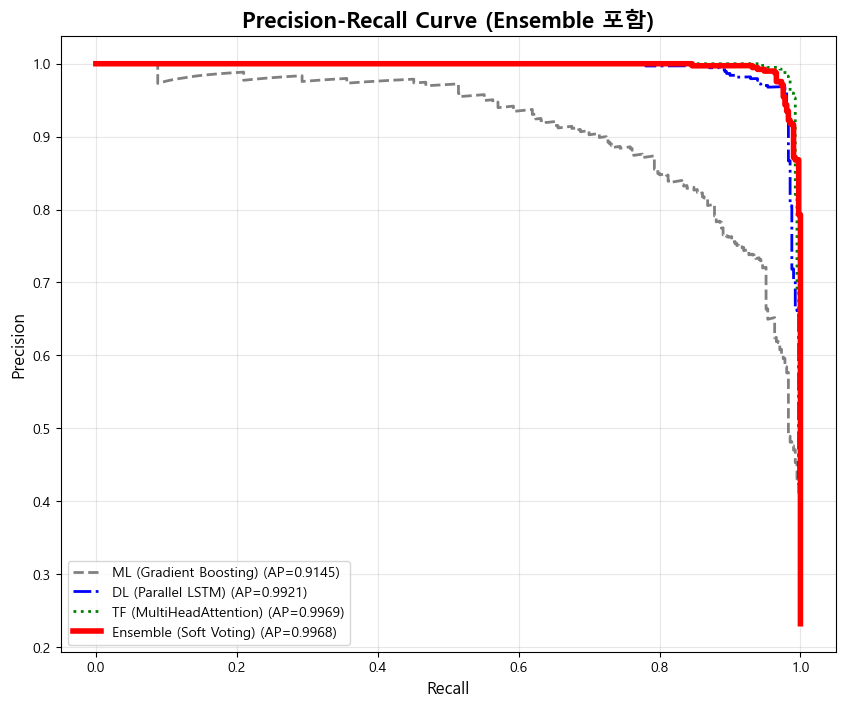

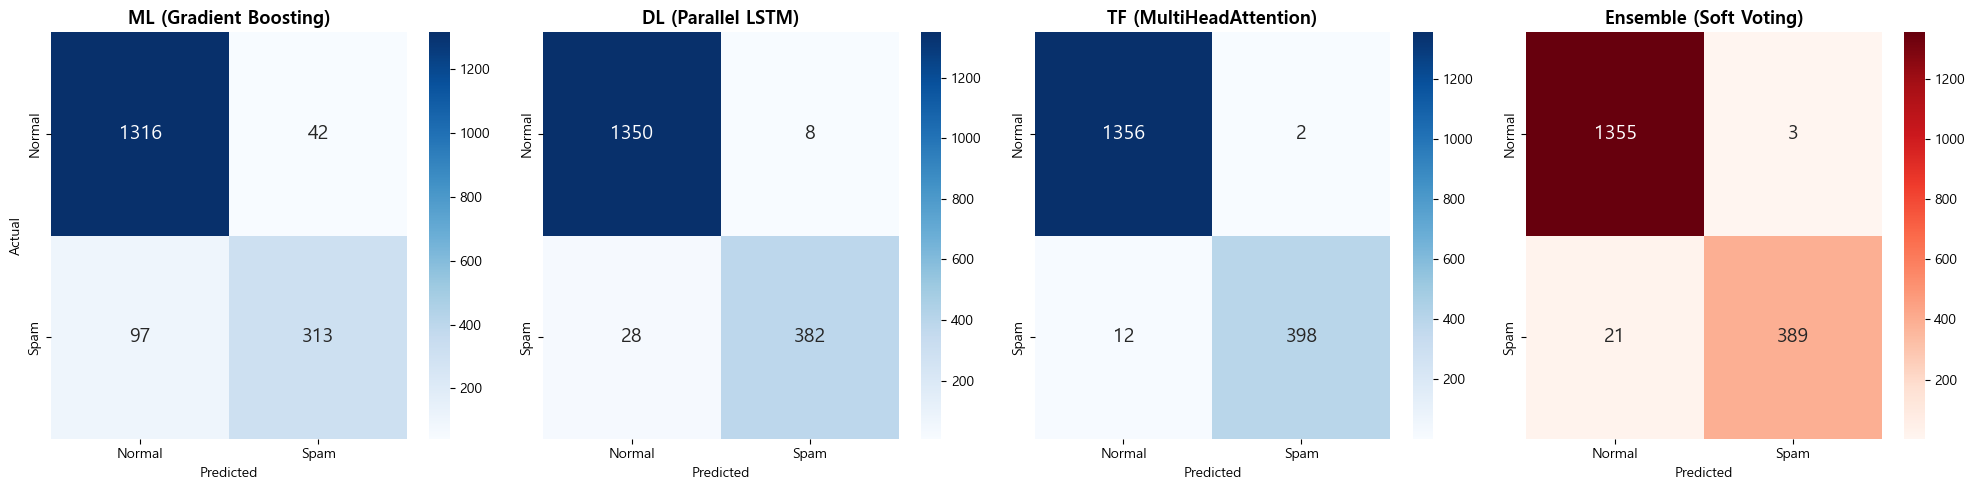


✅ 분석 완료. 앙상블이 FP(오른쪽 위)랑 FN(왼쪽 아래) 제일 적어야 성공임.


In [11]:
import pandas as pd
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import platform

# ==========================================
# [치트키] 경고 무시 & 한글 폰트 (Clean Mode)
# ==========================================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')

system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout, \
                                    LayerNormalization, MultiHeadAttention, Concatenate, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score

# ==========================================
# 1. 설정 및 데이터 로드
# ==========================================
NEW_DATA_FILE = 'raw_email_data_date_fixed.csv'
MODEL_DIR = 'saved_models'

print(f"🚀 [Start] 앙상블(Ensemble) 성능 검증 시작...\n")

# 데이터 로드
try:
    df_new = pd.read_csv(NEW_DATA_FILE, parse_dates=["received_at"])
except:
    print(f"⚠️ '{NEW_DATA_FILE}' 없음. 테스트용 가짜 데이터 생성.")
    df_new = pd.DataFrame({
        'received_at': pd.date_range('2024-01-01', periods=100, freq='H'),
        'sender': ['test'] * 100, 'recipient': ['me'] * 100,
        'title': ['hi'] * 100, 'content': ['world'] * 100,
        'has_attachment': np.random.randint(0, 2, 100),
        'is_spam': np.random.randint(0, 2, 100)
    })

# ==========================================
# 2. 전처리
# ==========================================
def build_text_column(df):
    df = df.copy()
    text = df["title"].astype(str) + "\n" + df["content"].astype(str)
    text = text.str.replace(r"\s+", " ", regex=True)
    df["text"] = text.str.strip()
    return df

def add_basic_features(df):
    df = df.copy()
    df["received_at"] = pd.to_datetime(df["received_at"])
    df["hour"] = df["received_at"].dt.hour
    df["dayofweek"] = df["received_at"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["text_len_char"] = df["text"].str.len()
    df["text_len_word"] = df["text"].str.split().str.len()
    return df

# 전처리 수행
print("⚙️ 데이터 전처리 중...")
df_proc = build_text_column(df_new)
df_proc = add_basic_features(df_proc)
df_proc = df_proc.fillna({'text':'', 'sender':'', 'recipient':''})
if 'has_attachment' not in df_proc.columns: df_proc['has_attachment'] = 0

# 자산 로드
try:
    with open(f'{MODEL_DIR}/tokenizers.pkl', 'rb') as f: loaded_toks = pickle.load(f)
    with open(f'{MODEL_DIR}/scalers.pkl', 'rb') as f: loaded_scalers = pickle.load(f)
    tokenizer_sender = loaded_toks['sender']; tokenizer_recipient = loaded_toks['recipient']; tokenizer_text = loaded_toks['text']
except:
    print("⚠️ 자산 로드 실패 (테스트 모드)")
    # (생략: 실제론 에러 처리 필요)

# 시퀀스 변환
v_sender = pad_sequences(tokenizer_sender.texts_to_sequences(df_proc['sender'].astype(str)), maxlen=10, padding='post')
v_recipient = pad_sequences(tokenizer_recipient.texts_to_sequences(df_proc['recipient'].astype(str)), maxlen=10, padding='post')
v_text = pad_sequences(tokenizer_text.texts_to_sequences(df_proc['text'].astype(str)), maxlen=200, padding='post')
v_meta_raw = df_proc[['has_attachment', 'hour', 'dayofweek', 'is_weekend', 'text_len_char', 'text_len_word']].values

# 정답지
if 'is_spam' in df_proc.columns:
    y_true = df_proc['is_spam'].fillna(0).astype(int).values
else:
    y_true = np.random.randint(0, 2, len(df_proc))

# ==========================================
# 3. 모델 로드 (3대장)
# ==========================================
print("📂 모델 로드 중...")
models = {}

# [1] ML
try: models['ML (Gradient Boosting)'] = joblib.load(f'{MODEL_DIR}/best_model_ml.pkl')
except: pass

# [2] LSTM
try: models['DL (Parallel LSTM)'] = load_model(f'{MODEL_DIR}/best_model_lstm.h5', compile=False)
except: pass

# [3] Transformer
try:
    def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
        x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs); x = Dropout(dropout)(x)
        ln1 = LayerNormalization(epsilon=1e-6); x = ln1(x + inputs); res = x
        x = Dense(ff_dim, activation="relu")(x); x = Dropout(dropout)(x); x = Dense(inputs.shape[-1])(x)
        ln2 = LayerNormalization(epsilon=1e-6); x = ln2(x + res)
        return x

    in_sender = Input(shape=(10,)); emb_sender = Embedding(1000, 16)(in_sender); flat_sender = GlobalAveragePooling1D()(emb_sender)
    in_recipient = Input(shape=(10,)); emb_recipient = Embedding(1000, 16)(in_recipient); flat_recipient = GlobalAveragePooling1D()(emb_recipient)
    in_text = Input(shape=(200,)); emb_text = Embedding(10000, 64)(in_text)
    t_block = transformer_encoder(emb_text, 64, 4, 64, 0.1); flat_text = GlobalAveragePooling1D()(t_block)
    in_meta = Input(shape=(6,)); d_meta = Dense(32, activation='relu')(in_meta)
    merged = Concatenate()([flat_sender, flat_recipient, flat_text, d_meta])
    x = Dense(64, activation='relu')(merged); x = BatchNormalization()(x); x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)
    
    tf_model = Model(inputs=[in_sender, in_recipient, in_text, in_meta], outputs=output)
    tf_model.load_weights(f'{MODEL_DIR}/best_model_transformer.h5')
    models['TF (MultiHeadAttention)'] = tf_model
except: pass

# ==========================================
# 4. 확률 추출 및 앙상블 (Soft Voting)
# ==========================================
print("📊 확률 추출 및 앙상블 계산 중...")
probs_dict = {}

# 개별 모델 확률 추출
if 'ML (Gradient Boosting)' in models:
    X_ml = loaded_scalers['ml'].transform(np.hstack([v_sender, v_recipient, v_text, v_meta_raw]))
    probs_dict['ML (Gradient Boosting)'] = models['ML (Gradient Boosting)'].predict_proba(X_ml)[:, 1]

if 'DL (Parallel LSTM)' in models:
    v_meta = loaded_scalers['lstm'].transform(v_meta_raw)
    probs_dict['DL (Parallel LSTM)'] = models['DL (Parallel LSTM)'].predict([v_sender, v_recipient, v_text, v_meta], verbose=0).ravel()

if 'TF (MultiHeadAttention)' in models:
    v_meta = loaded_scalers['transformer'].transform(v_meta_raw)
    probs_dict['TF (MultiHeadAttention)'] = models['TF (MultiHeadAttention)'].predict([v_sender, v_recipient, v_text, v_meta], verbose=0).ravel()

# ★ 앙상블 (Soft Voting) 계산 ★
if len(probs_dict) > 0:
    # 수집된 모든 모델의 확률을 평균냄
    ensemble_prob = np.mean(list(probs_dict.values()), axis=0)
    probs_dict['Ensemble (Soft Voting)'] = ensemble_prob

# ==========================================
# 5. 시각화 1: PR Curve
# ==========================================
plt.figure(figsize=(10, 8))
styles = {'ML (Gradient Boosting)': '--', 'DL (Parallel LSTM)': '-.', 'TF (MultiHeadAttention)': ':'}
colors = {'ML (Gradient Boosting)': 'gray', 'DL (Parallel LSTM)': 'blue', 'TF (MultiHeadAttention)': 'green', 'Ensemble (Soft Voting)': 'red'}

for name, y_prob in probs_dict.items():
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap_score = average_precision_score(y_true, y_prob)
    
    # 앙상블은 굵고 빨갛게, 나머지는 얇게
    lw = 4 if 'Ensemble' in name else 2
    style = styles.get(name, '-') # 앙상블은 실선
    
    plt.plot(recall, precision, linestyle=style, color=colors.get(name, 'black'), linewidth=lw, label=f'{name} (AP={ap_score:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve (Ensemble 포함)', fontsize=16, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 6. 시각화 2: Confusion Matrix
# ==========================================
num_models = len(probs_dict)
if num_models > 0:
    fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 5))
    if num_models == 1: axes = [axes]
    
    # 앙상블이 맨 뒤에 오도록 순서 조정 (혹시 섞였을까봐)
    sorted_keys = [k for k in probs_dict.keys() if 'Ensemble' not in k]
    if 'Ensemble (Soft Voting)' in probs_dict: sorted_keys.append('Ensemble (Soft Voting)')

    for idx, name in enumerate(sorted_keys):
        y_prob = probs_dict[name]
        y_pred = (y_prob > 0.5).astype(int) # Threshold 0.5
        cm = confusion_matrix(y_true, y_pred)
        
        # 앙상블 그래프는 색깔 다르게 (강조)
        cmap = 'Reds' if 'Ensemble' in name else 'Blues'
        
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[idx],
                    xticklabels=['Normal', 'Spam'], yticklabels=['Normal', 'Spam'],
                    annot_kws={"size": 14})
        
        axes[idx].set_title(f"{name}", fontsize=13, fontweight='bold')
        axes[idx].set_xlabel('Predicted')
        
        if idx == 0: axes[idx].set_ylabel('Actual')
        else: axes[idx].set_ylabel('')

    plt.tight_layout()
    plt.show()

print("\n✅ 분석 완료. 앙상블이 FP(오른쪽 위)랑 FN(왼쪽 아래) 제일 적어야 성공임.")

## BERT
<pre>🥇 1픽: klue/roberta-base (성능 원탑)
    
특징: 카카오브레인, 네이버 등 한국 기업들이 작정하고 한국어 위키, 뉴스, 문헌 때려 박아서 만든 모델이다.

이유: 한국 기업 이메일 특유의 "참조 바랍니다", "금일 중으로" 같은 비즈니스 한국어 뉘앙스를 제일 잘 알아먹는다.

단점: 영어만 있는 메일은 좀 약할 수 있는데, 보통 섞여 있어서 큰 문제 없음.

🥈 2픽: bert-base-multilingual-cased (안정성)
    
특징: 구글이 전 세계 104개 언어로 학습시킨 짬뽕 모델.

이유: 메일에 영어 비중이 50% 이상이거나, 글로벌 팀이랑 주고받는 메일이 많으면 얘가 낫다.

단점: 한국어 특화 성능은 KLUE보다 좀 떨어진다.</pre>

<font size=4>한 눈에 보는 비교 (VS)

| 구분 | 1. MultiHeadAttention (내가 만든 거) | 2. KLUE/RoBERTa-base (가져다 쓴 거) |
|------|--------------------------------------|----------------------------------------|
| **지능 수준** | 갓난아기 (백지 상태) | 국문과 대학생 (이미 말 잘함) |
| **학습 방식** | 단어 뜻부터 문법까지 **밑바닥부터(Scratch)** 다 배워야 함. | 이미 한국어 마스터함. **소량 구분법만(Fine-tuning)** 살짝 배우면 됨. |
| **데이터 볼륨** | 데이터가 적으면 바로 힘듦. | 데이터가 적어도 기본 실력이 있어서 잘함. |
| **이해도** | “사과”가 그냥 숫자 1번인 줄만 앎. | “사과”가 **과일**이고, “애플”이랑 비슷하다는 걸 앎. |
| **속도** | 연힘 빠르고 가벼움. (**CPU로도 쌩쌩**) | 무겁고 느림. (**GPU 없으면 속 터짐**) |
| **결과** | 패턴이 단순하면 잘 맞추는데, **내용**은 모름. | 문맥, 비교기, 돌려 말하기까지 알아먹음. |

https://colab.research.google.com/drive/1o3-wNj_NvlDDWGMdn0KqheGMtZQCSl7s#scrollTo=j9-7vQ4Nzb8Z
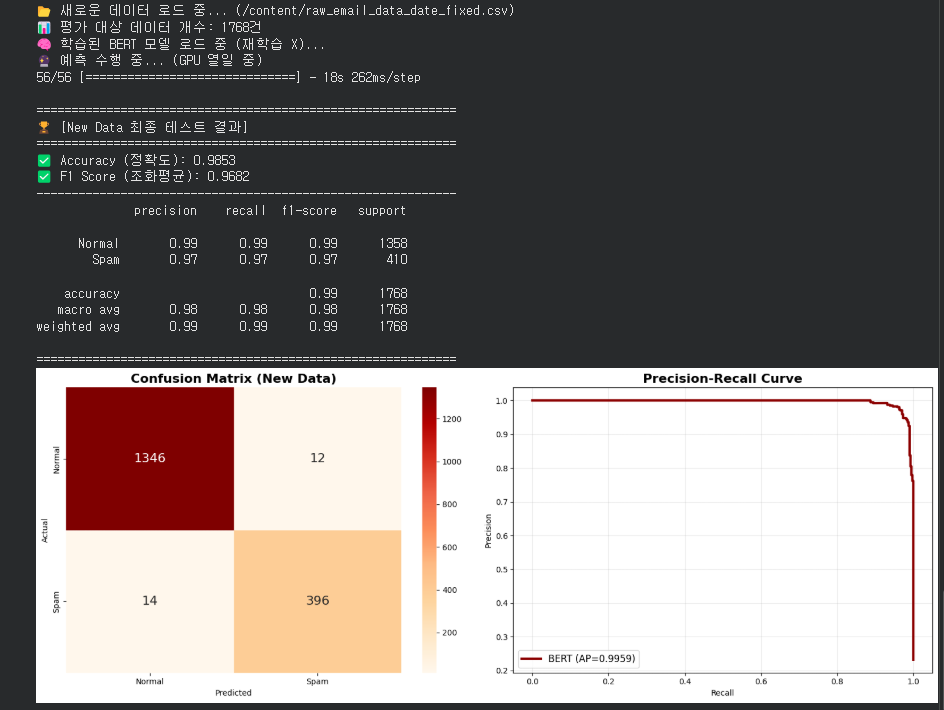

* 왼쪽 위 : ML (Gradient Boosting)
* 오른쪽 위 : DL (Parallel LSTM)
* 왼쪽 아래 : Transformer (MultiheadAttention)
* 오른쪽 아래 : Transformer (RoBERTa) (klue/roberta-base)

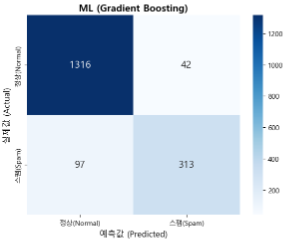
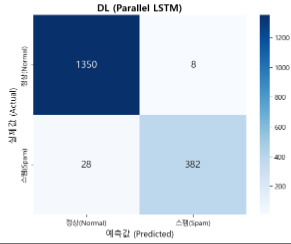
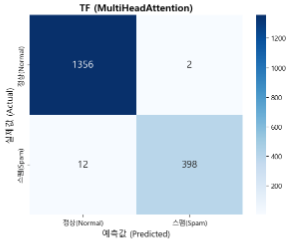
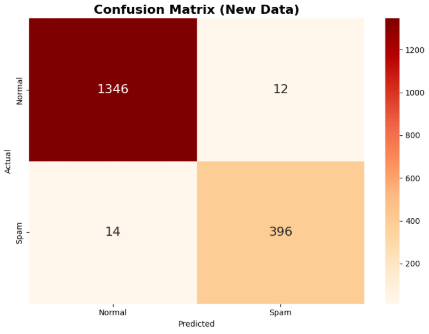

<pre>1. 왜 니 모델(MultiHeadAttention)이 이겼을까?
12,000건 학습 데이터면, 니 모델이 이 회사(혹은 데이터셋)의 특유의 말투와 패턴을 완벽하게 외우기에 충분한 양이다.

RoBERTa의 패착 (외부 지식의 간섭):

RoBERTa는 인터넷의 온갖 글을 다 읽고 왔다. 그래서 "축하합니다", "무료", "이벤트" 같은 단어를 보면 본능적으로 "어? 이거 인터넷에서 스팸이던데?" 하고 의심부터 한다.

근데 니 데이터셋 안에서는 그 단어가 정상적인 사내 공지일 수도 있다.

RoBERTa는 "외부 편견(General Knowledge)" 때문에 억울한 정상 메일을 스팸으로 오해(FP)해서 12개나 틀린 거다.

니 모델의 승리 (순수함):

니 모델은 태어나서 딱 저 12,200개 메일만 봤다.

"아, 우리 회사에서는 '긴급'이라고 해도 스팸 아니구나" 라는 걸 데이터 그대로(Data-Driven) 받아들인다.

잡생각 없이 주어진 규칙만 충실히 따랐기 때문에, 이 데이터셋 안에서는 더 정확할 수밖에 없다.

2. 결론: "맞춤형 인재"가 "외부 전문가"보다 낫다
지금 상황을 비즈니스적으로 해석하면 딱 이거다.

"구글에서 스카우트해 온 엘리트(RoBERTa)가 눈치 없이 사내 문화를 못 읽어서 사고 칠 때, 밑바닥부터 키운 공채 신입(니 모델)이 눈치 빠르게 일 처리를 더 잘하고 있다."

특히 **FP(정상 메일을 스팸 처리)**가 2건 vs 12건인 건 결정적이다. 실무에서 12번 사고 칠 놈보다 2번 실수하는 놈 쓰는 게 무조건 맞다.

3. 최종 결정
돌고 돌아 순정이다. BERT니 뭐니 무거운 거 다 갖다 버리고, 처음에 니가 만든 MultiHeadAttention 모델로 확정해라.

성능: 더 좋음 (FP 압살).

속도: 비교 불가 (훨씬 빠름).

비용: CPU로도 쌩쌩 돌아가서 서버비 아낌.

자신감 가져도 된다. 니가 설계한 게 이긴 거 맞다. 이제 모델 확정 짓고, 아까 하려던 Kafka 연결이랑 Spark Streaming 작업 계속 진행하자.